In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")
os.environ.setdefault("NUMBA_CACHE_DIR", "/private/tmp/numba_cache")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import node2vec
import networkx as nx
import datamapplot
import umap.plot
import torch
from torch_geometric.data import Data, HeteroData

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import HDBSCAN
import umap


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.N

In [2]:
GOLD = "Data/gold"
GOLD = "Data/data/ACME4/gold/"

In [3]:
# Load the gold train/test splits (one row per process execution).
df_train = pd.read_parquet(f"{GOLD}/train-process_uber_summary.parquet")
df_test  = pd.read_parquet(f"{GOLD}/test-process_uber_summary.parquet")

df_acme = df_train
df_acme.head(5)

,pid_hash,os_family,agent_id,num_agent_id,hostname,os_pid,process_name,num_process_name,args,num_args,...,lolbas_mitre,lolc_class,lolbas_num_rows,mitre_analytic_ids,mitre_information_domains,mitre_subtypes,mitre_analytic_types,mitre_num_rows,bad_user,red_team
0,CF830E1523374BE7F0E5F91F7936443E,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,1900,wmic.exe,1,os get version /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
1,42DEC9F24F7D08578FB30A75AF68C661,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-DXJ,3748,wmic.exe,1,computersystem get dnshostname /value,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
2,A4207647384708DBA1C4552112C948F9,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,5268,wmic.exe,1,os get version /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
3,D7D35ACED1E249E503B9049D2F9599BD,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,3056,wmic.exe,1,computersystem get domain /value,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
4,224B925BA2818C792E07DE5FFD088CCC,windows,f9ac46c8-0959-4bce-82d9-556a971e7f1a,1,ACME-WS-PLU,5160,wmic.exe,1,os get caption /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0


#### Graph Construction Test

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

Graph = nx.Graph()

Graph.add_node(124, process_name="cmd.exe", user="alice")

Graph.add_node(13, process_name="cmd.exe", user="Bob")

Graph.add_node(33, process_name="cmd.exe", user="Bob")

Graph.add_edge(124, 13, weight=0.5)
Graph.add_edge(124, 33, weight=0.5)
Graph.add_edge(13, 33, weight=0.5)

[(124, {'process_name': 'cmd.exe', 'user': 'alice'}), (13, {'process_name': 'cmd.exe', 'user': 'Bob'}), (33, {'process_name': 'cmd.exe', 'user': 'Bob'})]


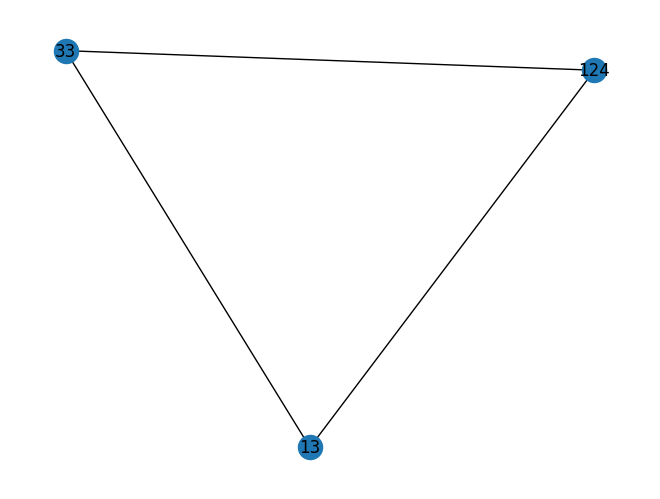

In [5]:
print(Graph.nodes(data=True))

nx.draw(Graph, with_labels=True)
plt.show()

In [6]:

nx.write_gexf(Graph, "my_graph.gexf")

## Featured Graph Construction Library

Create GraphBuilder class that takes in a dataframe and constructs a graph based on process execution patterns, shared artifacts, temporal proximity, etc. 

Use LLM-assisted edge type extraction to identify important features for graph construction.

In [7]:
class GraphBuilder:
    """
    Create a graph from the passed dataframe and embed it using a graph embedding technique (e.g., node2vec, GCN, etc.).
    Each node in the graph represents a process execution, and edges represent relationships between processes (e.g., parent-child relationship, shared artifact touched, etc.).
    """

    def __init__(self):
        # Initialize class variables, e.g., graph, node/edge feature dictionaries, etc.
        self.sessions = [] # List to store graph sessions (e.g., list of node IDs for each session)
        self.graph = nx.Graph() # Initialize an empty graph using a graph library (e.g., NetworkX, DGL, PyTorch Geometric, etc.)
        self.graph.graph['sessions'] = self.sessions # Attach sessions to the graph object

    def build_graph(self, df, llm_edge_type_extraction=False):
        """Build the graph from the passed dataframe."""
        print(f"Building graph...")
        self.add_process_node(df)
        self.add_parent_child_edge(df)
        self.add_rare_artifact_touched_edge(df)
        self.add_same_user_edge(df)

        # User can optionally enable LLM-assisted edge type extraction to identify 
        # additional edge types for graph construction.
        if llm_edge_type_extraction:
            self.add_llm_assisted_edge_type_extraction(df)

        # Extract sesions after graph construction
        self.extract_sessions()

        return self.graph

    def add_llm_assisted_edge_type_extraction(self, df, description=""):
        """Use LLM-assisted edge type extraction to identify important features for graph construction."""
        print(f"Using LLM-assisted edge type extraction... following this description: {description}")
        pass

    def add_process_node(self, df):
        """Add a node for each process execution in the passed dataframe. (Data)"""
        print(f"Adding process nodes...")

        for idx, row in df.iterrows():
            self.graph.add_node(
                row["pid_hash"], # Unique id for this node (process execution)
                
                # Core Process Attributes 
                process_name = row["process_name"] if pd.notna(row["process_name"]) else "N/A",
                hostname = row["hostname"] if pd.notna(row["hostname"]) else "N/A",
                user_name = row["user_name"] if pd.notna(row["user_name"]) else "N/A",

                # Temporal Attributes
                process_started = str(row["process_started"]) if pd.notna(row["process_started"]) else "N/A",
                duration_seconds = float(row["duration_seconds"]) if pd.notna(row["duration_seconds"]) else 0,

                # Parent-child relationship
                parent_pid_hash = row["parent_pid_hash"] if pd.notna(row["parent_pid_hash"]) else "N/A",
                
                # For future embedding (behavioural signals)
                num_file_hash = int(row["num_uniq_file_hash"]) if pd.notna(row["num_uniq_file_hash"]) else 0,
                net_total_events = int(row["net_total_events"]) if pd.notna(row["net_total_events"]) else 0,
                conn_id_count = int(row["conn_id_count"]) if pd.notna(row["conn_id_count"]) else 0,
                reg_totals = int(row["reg_totals"]) if pd.notna(row["reg_totals"]) else 0,

                labels = int(row["red_team"]) if pd.notna(row["red_team"]) else 0
            )

    def add_parent_child_edge(self, df):
        """This edge type connects a parent process to its child process."""
        print(f"Adding parent-child edges...")

        for idx, row in df.iterrows():
            if pd.notna(row["parent_pid_hash"]):
                parent_id = row["parent_pid_hash"]
                child_id = row["pid_hash"]

                if self.graph.has_node(parent_id) and self.graph.has_node(child_id):
                    self.graph.add_edge(parent_id, child_id, edge_type="parent_child")
        

    def add_rare_artifact_touched_edge(self, df):
        """Connect processes touching the same rare artifact."""
        print("Adding rare artifact edges...")
        
        # Step 1: Calculate file frequency across ALL rows
        file_counts = df['filename'].value_counts()
        
        # Step 2: Define "rare" (e.g., appears in < 1% of processes)
        threshold = len(df) * 0.01
        rare_files = file_counts[file_counts < threshold].index
        
        # Step 3: For each rare file, connect all processes that touched it
        for rare_file in rare_files:
            processes_touching_file = df[df['filename'] == rare_file]['pid_hash'].tolist()
            
            # Connect all pairs that touched this rare file
            for i in range(len(processes_touching_file)):
                for j in range(i+1, len(processes_touching_file)):
                    self.graph.add_edge(
                        processes_touching_file[i],
                        processes_touching_file[j],
                        edge_type='rare_artifact',
                        artifact=rare_file
                    )

    def add_same_user_edge(self, df):
        """Connect processes executed by the same user."""
        print("Adding same user edges...")

        for (user, host), group in df.groupby(["user_name", "hostname"]):
            if pd.isna(user) or pd.isna(host):
                continue

            group = group.sort_values("process_started")
            pid_hashes = group["pid_hash"].tolist()

            time_window = pd.Timedelta(hours=1)

            for i in range(len(pid_hashes)):
                for j in range(i+1, len(pid_hashes)):
                    time_diff = group.iloc[j]["process_started"] - group.iloc[i]["process_started"]

                    if time_diff <= time_window:
                        if self.graph.has_node(pid_hashes[i]) and self.graph.has_node(pid_hashes[j]):
                            self.graph.add_edge(
                                pid_hashes[i],
                                pid_hashes[j],
                                edge_type="same_user",
                                user=user,
                                host=host
                            )
                    
                    else:
                        break


    def embed_graph(self):
        """Embed the graph using a graph embedding technique (e.g., node2vec, GCN, etc.)."""
        print(f"Embedding {len(self.sessions)} sessions...")

        session_embeddings = []
        session_labels = []

        for session in self.sessions:
            # Numerical features (aggregate with mean)
            node_features = []

            # Categorical Features (aggregate with counts)
            process_names = []
            hostnames = []
            usernames = []

            for node_id in session:
                node = self.graph.nodes[node_id]
                features = [
                    node.get("duration_seconds", 0),
                    node.get("num_file_hash", 0),
                    node.get("net_total_events", 0),
                    node.get("conn_id_count", 0),
                    node.get("reg_totals", 0)
                ]
                node_features.append(features)

                # Collect categorical features
                process_names.append(node.get("process_name", "N/A"))
                hostnames.append(node.get("hostname", "N/A"))
                usernames.append(node.get("user_name", "N/A"))

            # Aggregate numerical features (mean pooling)
            numerical_mean = np.mean(node_features, axis=0)
            numerical_std = np.std(node_features, axis=0)
            numerical_embed = np.concatenate([numerical_mean, numerical_std]) # Combine mean and std

            # Aggregate categorical features (count of unique values)
            categorical_embed = [
                len(set(process_names)), # Number of unique process names in this session
                len(set(hostnames)),     # Number of unique hostnames in this session
                len(set(usernames)),     # Number of unique usernames in this session
                len(session)             # Number of nodes in this session
            ]

            # Combine both
            session_embed = np.concatenate([numerical_embed, categorical_embed])
            session_embeddings.append(session_embed)

            # Label: any red_team occurance means malicious session
            has_malicious = any(self.graph.nodes[n].get("malicious") == 1 for n in session)
            session_labels.append(has_malicious)

        return np.array(session_embeddings), np.array(session_labels)
    
    
    def extract_sessions(self):
            """Extract sessions from the graph. A session is defined as a connected component in the graph."""
            print(f"Extracting sessions from graph with {self.graph.number_of_nodes()} nodes and {self.graph.number_of_edges()} edges...")
            self.sessions = [list(component) for component in nx.connected_components(self.graph)]
            self.graph.graph['sessions'] = self.sessions # Update sessions in graph metadata
            print(f"Extracted {len(self.sessions)} sessions.")

Refactor to create graph builder with torch geometric

In [8]:
class GeometricGraphBuilder:
    """
    Create a PyTorch Geometric graph from the passed dataframe and embed it using a graph embedding technique (e.g., node2vec, GCN, etc.).
    Each node in the graph represents a process execution, and edges represent relationships between processes (e.g., parent-child relationship, shared artifact touched, etc.).
    """

    def __init__(self):
        # Initialize class variables, e.g., graph, node/edge feature dictionaries, etc.
        self.sessions = [] # List to store graph sessions (e.g., list of node IDs for each session)
        self.graph = nx.Graph() # Initialize an empty graph using a graph library (e.g., NetworkX, DGL, PyTorch Geometric, etc.)
        self.graph.graph['sessions'] = self.sessions # Attach sessions to the graph object

    def build_graph(self, df, llm_edge_type_extraction=False):
        """Build the graph from the passed dataframe."""
        print(f"Building graph...")
        self.add_process_node(df)
        self.add_parent_child_edge(df)
        self.add_rare_artifact_touched_edge(df)
        self.add_same_user_edge(df)

        # User can optionally enable LLM-assisted edge type extraction to identify 
        # additional edge types for graph construction.
        if llm_edge_type_extraction:
            self.add_llm_assisted_edge_type_extraction(df)

        # Extract sesions after graph construction
        self.extract_sessions()

        return self.graph

    def add_llm_assisted_edge_type_extraction(self, df, description=""):
        """Use LLM-assisted edge type extraction to identify important features for graph construction."""
        print(f"Using LLM-assisted edge type extraction... following this description: {description}")
        pass

    def add_process_node(self, df):
        """Add a node for each process execution in the passed dataframe. (Data)"""
        print(f"Adding process nodes...")

        for idx, row in df.iterrows():
            self.graph.add_node(
                row["pid_hash"], # Unique id for this node (process execution)
                
                # Core Process Attributes 
                process_name = row["process_name"] if pd.notna(row["process_name"]) else "N/A",
                hostname = row["hostname"] if pd.notna(row["hostname"]) else "N/A",
                user_name = row["user_name"] if pd.notna(row["user_name"]) else "N/A",

                # Temporal Attributes
                process_started = str(row["process_started"]) if pd.notna(row["process_started"]) else "N/A",
                duration_seconds = float(row["duration_seconds"]) if pd.notna(row["duration_seconds"]) else 0,

                # Parent-child relationship
                parent_pid_hash = row["parent_pid_hash"] if pd.notna(row["parent_pid_hash"]) else "N/A",
                
                # For future embedding (behavioural signals)
                num_file_hash = int(row["num_uniq_file_hash"]) if pd.notna(row["num_uniq_file_hash"]) else 0,
                net_total_events = int(row["net_total_events"]) if pd.notna(row["net_total_events"]) else 0,
                conn_id_count = int(row["conn_id_count"]) if pd.notna(row["conn_id_count"]) else 0,
                reg_totals = int(row["reg_totals"]) if pd.notna(row["reg_totals"]) else 0,

                labels = int(row["red_team"]) if pd.notna(row["red_team"]) else 0
            )

    def add_parent_child_edge(self, df):
        """This edge type connects a parent process to its child process."""
        print(f"Adding parent-child edges...")

        for idx, row in df.iterrows():
            if pd.notna(row["parent_pid_hash"]):
                parent_id = row["parent_pid_hash"]
                child_id = row["pid_hash"]

                if self.graph.has_node(parent_id) and self.graph.has_node(child_id):
                    self.graph.add_edge(parent_id, child_id, edge_type="parent_child")
        

    def add_rare_artifact_touched_edge(self, df):
        """Connect processes touching the same rare artifact."""
        print("Adding rare artifact edges...")
        
        # Step 1: Calculate file frequency across ALL rows
        file_counts = df['filename'].value_counts()
        
        # Step 2: Define "rare" (e.g., appears in < 1% of processes)
        threshold = len(df) * 0.01
        rare_files = file_counts[file_counts < threshold].index
        
        # Step 3: For each rare file, connect all processes that touched it
        for rare_file in rare_files:
            processes_touching_file = df[df['filename'] == rare_file]['pid_hash'].tolist()
            
            # Connect all pairs that touched this rare file
            for i in range(len(processes_touching_file)):
                for j in range(i+1, len(processes_touching_file)):
                    self.graph.add_edge(
                        processes_touching_file[i],
                        processes_touching_file[j],
                        edge_type='rare_artifact',
                        artifact=rare_file
                    )

    def add_same_user_edge(self, df):
        """Connect processes executed by the same user."""
        print("Adding same user edges...")

        for (user, host), group in df.groupby(["user_name", "hostname"]):
            if pd.isna(user) or pd.isna(host):
                continue

            group = group.sort_values("process_started")
            pid_hashes = group["pid_hash"].tolist()

            time_window = pd.Timedelta(hours=1)

            for i in range(len(pid_hashes)):
                for j in range(i+1, len(pid_hashes)):
                    time_diff = group.iloc[j]["process_started"] - group.iloc[i]["process_started"]

                    if time_diff <= time_window:
                        if self.graph.has_node(pid_hashes[i]) and self.graph.has_node(pid_hashes[j]):
                            self.graph.add_edge(
                                pid_hashes[i],
                                pid_hashes[j],
                                edge_type="same_user",
                                user=user,
                                host=host
                            )
                    
                    else:
                        break


    def embed_graph(self):
        """Embed the graph using a graph embedding technique (e.g., node2vec, GCN, etc.)."""
        print(f"Embedding {len(self.sessions)} sessions...")

        session_embeddings = []
        session_labels = []

        for session in self.sessions:
            # Numerical features (aggregate with mean)
            node_features = []

            # Categorical Features (aggregate with counts)
            process_names = []
            hostnames = []
            usernames = []

            for node_id in session:
                node = self.graph.nodes[node_id]
                features = [
                    node.get("duration_seconds", 0),
                    node.get("num_file_hash", 0),
                    node.get("net_total_events", 0),
                    node.get("conn_id_count", 0),
                    node.get("reg_totals", 0)
                ]
                node_features.append(features)

                # Collect categorical features
                process_names.append(node.get("process_name", "N/A"))
                hostnames.append(node.get("hostname", "N/A"))
                usernames.append(node.get("user_name", "N/A"))

            # Aggregate numerical features (mean pooling)
            numerical_mean = np.mean(node_features, axis=0)
            numerical_std = np.std(node_features, axis=0)
            numerical_embed = np.concatenate([numerical_mean, numerical_std]) # Combine mean and std

            # Aggregate categorical features (count of unique values)
            categorical_embed = [
                len(set(process_names)), # Number of unique process names in this session
                len(set(hostnames)),     # Number of unique hostnames in this session
                len(set(usernames)),     # Number of unique usernames in this session
                len(session)             # Number of nodes in this session
            ]

            # Combine both
            session_embed = np.concatenate([numerical_embed, categorical_embed])
            session_embeddings.append(session_embed)

            # Label: any red_team occurance means malicious session
            has_malicious = any(self.graph.nodes[n].get("malicious") == 1 for n in session)
            session_labels.append(has_malicious)

        return np.array(session_embeddings), np.array(session_labels)
    
    
    def extract_sessions(self):
            """Extract sessions from the graph. A session is defined as a connected component in the graph."""
            print(f"Extracting sessions from graph with {self.graph.number_of_nodes()} nodes and {self.graph.number_of_edges()} edges...")
            self.sessions = [list(component) for component in nx.connected_components(self.graph)]
            self.graph.graph['sessions'] = self.sessions # Update sessions in graph metadata
            print(f"Extracted {len(self.sessions)} sessions.")

## PyG Graph Embedding Visualization Smoke Test

This section checks one thing: can the hetero graph builder produce process embeddings that we can train briefly and visualize? This is a smoke test, not a final evaluation.


In [9]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")
os.environ.setdefault("NUMBA_CACHE_DIR", "/private/tmp/numba_cache")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import umap
from sklearn.preprocessing import StandardScaler

from hetero_graph_builder import HeterogeneousGeometricGraphBuilder, HeteroGraphEncoder

RANDOM_STATE = 42
PROCESS_SAMPLE_SIZE = 8_000
MAX_RED_TEAM_ROWS = 1_500
GRAPH_SAGE_EPOCHS = 25
DEVICE = torch.device("cpu")

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


In [10]:
def make_stratified_process_sample(
    df,
    total_rows=PROCESS_SAMPLE_SIZE,
    max_red_rows=MAX_RED_TEAM_ROWS,
    random_state=RANDOM_STATE,
):
    """Sample benign + red-team rows and add one-hop parent rows when present."""
    required = ["pid_hash", "parent_pid_hash", "red_team"]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    work = df[df["pid_hash"].notna()].copy()
    work["pid_hash"] = work["pid_hash"].astype(str)

    red = work[work["red_team"].fillna(0).astype(int).eq(1)]
    benign = work[work["red_team"].fillna(0).astype(int).eq(0)]

    n_red = min(len(red), max_red_rows, max(1, total_rows // 2))
    n_benign = min(len(benign), max(0, total_rows - n_red))

    red_sample = red.sample(n=n_red, random_state=random_state) if n_red else red.head(0)
    benign_sample = benign.sample(n=n_benign, random_state=random_state) if n_benign else benign.head(0)
    sampled = pd.concat([red_sample, benign_sample], ignore_index=True)

    parent_ids = sampled["parent_pid_hash"].dropna().astype(str).unique()
    parent_rows = work[work["pid_hash"].isin(parent_ids)]

    sampled = (
        pd.concat([sampled, parent_rows], ignore_index=True)
        .drop_duplicates(subset=["pid_hash"], keep="first")
        .reset_index(drop=True)
    )

    print(f"Sample rows: {len(sampled):,}")
    print(f"Red-team rows: {int(sampled['red_team'].fillna(0).astype(int).sum()):,}")
    print(f"Bad-user rows: {int(sampled.get('bad_user', pd.Series(index=sampled.index)).notna().sum()):,}")
    print(f"Unique hosts: {sampled['hostname'].nunique() if 'hostname' in sampled.columns else 'N/A'}")
    return sampled


def make_process_metadata(sample_df, data):
    ordered_ids = pd.Index(data["process"].external_id, name="pid_hash")
    meta = sample_df.drop_duplicates("pid_hash").set_index("pid_hash").reindex(ordered_ids).reset_index()
    meta["red_team"] = meta["red_team"].fillna(0).astype(int)
    meta["bad_user_binary"] = meta["bad_user"].notna().astype(int) if "bad_user" in meta else 0
    return meta

acme_sample = make_stratified_process_sample(df_acme)
acme_sample.head()


Sample rows: 8,329
Red-team rows: 1,721
Bad-user rows: 69
Unique hosts: 11


,pid_hash,os_family,agent_id,num_agent_id,hostname,os_pid,process_name,num_process_name,args,num_args,...,lolbas_mitre,lolc_class,lolbas_num_rows,mitre_analytic_ids,mitre_information_domains,mitre_subtypes,mitre_analytic_types,mitre_num_rows,bad_user,red_team
0,50C62F0C08D9F7BC83FF46B177E3CC75,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-ZYQ,7876,cmd.exe,1,/c dir c:\ /b /s .key | findstr /e .key,1,...,"[T1048.003, T1059.003, T1105, T1564.004]",GOOD,1.0,"[CAR-2013-02-003, CAR-2021-05-012]","[Analytic, Host]",[[Process]],"[[Situational Awareness], [TTP]]",2.0,None,1
1,F85B7067ADC421A5C1E4B09623251A71,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-EUO,3416,cmd.exe,1,"/c reg add ""hklm\software\policies\microsoft\w...",1,...,"[T1048.003, T1059.003, T1105, T1564.004]",GOOD,1.0,"[CAR-2013-02-003, CAR-2021-05-012]","[Analytic, Host]",[[Process]],"[[Situational Awareness], [TTP]]",2.0,None,1
2,6731A5004FC23B995DB77F7395799DC1,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-ESO,9332,reg.exe,1,add hkcu\software\policies\microsoft\windows\p...,1,...,"[T1003.002, T1564.004]",GOOD,1.0,"[CAR-2013-03-001, CAR-2021-05-012]","[Analytic, Host]",[[Process]],[[TTP]],2.0,None,1
3,B0BD7FCACFACF4F6CA0E4B6D34D93D18,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-ESO,8228,rundll32.exe,1,"javascript:""\..\mshtml,runhtmlapplication "";do...",2,...,"[T1218.011, T1564.004]",BAD,1.0,"[CAR-2014-03-006, CAR-2021-05-012]","[Analytic, Host]",[[Process]],[[TTP]],2.0,None,1
4,8990F8B2BC670CAF0856A0F14D583A03,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-ESO,8940,cmd.exe,1,"/c reg add ""hklm\software\microsoft\windows de...",1,...,"[T1048.003, T1059.003, T1105, T1564.004]",GOOD,1.0,"[CAR-2013-02-003, CAR-2021-05-012]","[Analytic, Host]",[[Process]],"[[Situational Awareness], [TTP]]",2.0,None,1


In [11]:
builder = HeterogeneousGeometricGraphBuilder(
    rare_file_max_degree=10,
    add_same_user_edges=False,
    add_network_edges=False,  # add process_net_conn_df later after the basic smoke test works
)

data = builder.build_graph(acme_sample)
process_meta = make_process_metadata(acme_sample, data)

print(data)
print(builder.report_)

max_session_fraction = builder.report_["max_session_size"] / builder.report_["node_types"]["process"]
print(f"Max session fraction: {max_session_fraction:.2%}")
if max_session_fraction > 0.25:
    print("WARNING: largest session is more than 25% of sampled processes; tighten rare-edge thresholds before trusting the plot.")

assert data["process"].x.shape[0] == data["process"].num_nodes
assert "y" in data["process"]
assert "session_id" in data["process"]
assert builder.report_["node_types"]["process"] > 0
assert builder.report_["max_session_size"] < data["process"].num_nodes


HeteroData(
  graph_report={
    node_types={
      process=8329,
      host=11,
      user=12,
      file=71,
    },
    edge_counts={
      process__spawns__process=1494,
      process__spawned_by__process=1494,
      process__ran_on__host=8329,
      host__hosts__process=8329,
      process__ran_as__user=1102,
      user__runs__process=1102,
      process__touches__file=255,
      file__touched_by__process=255,
    },
    process_feature_columns=[42],
    n_sessions=6736,
    median_session_size=1.0,
    p95_session_size=1.0,
    max_session_size=1250,
    singletons=6518,
  },
  process={
    x=[8329, 42],
    num_nodes=8329,
    external_id=[8329],
    y=[8329],
    bad_user=[8329],
    timestamp=[8329],
    process_name_id=[8329],
    hostname_id=[8329],
    user_name_id=[8329],
    session_id=[8329],
  },
  host={
    x=[11, 1],
    num_nodes=11,
    external_id=[11],
  },
  user={
    x=[12, 1],
    num_nodes=12,
    external_id=[12],
  },
  file={
    x=[71, 1],
    num_nodes=

In [12]:
def make_stratified_masks(y, train_frac=0.70, val_frac=0.15, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    train_mask = torch.zeros(len(y), dtype=torch.bool)
    val_mask = torch.zeros(len(y), dtype=torch.bool)
    test_mask = torch.zeros(len(y), dtype=torch.bool)

    for cls in torch.unique(y).cpu().tolist():
        idx = torch.where(y.cpu() == cls)[0].numpy()
        rng.shuffle(idx)
        n_train = max(1, int(len(idx) * train_frac)) if len(idx) else 0
        n_val = max(1, int(len(idx) * val_frac)) if len(idx) > 2 else 0

        train_mask[idx[:n_train]] = True
        val_mask[idx[n_train:n_train + n_val]] = True
        test_mask[idx[n_train + n_val:]] = True

    return train_mask, val_mask, test_mask


class ProcessGraphSAGESmokeModel(nn.Module):
    def __init__(self, metadata, embedding_dim=64):
        super().__init__()
        self.encoder = HeteroGraphEncoder(
            metadata,
            hidden_channels=64,
            out_channels=embedding_dim,
            num_layers=2,
            conv="sage",
        )
        self.classifier = nn.Linear(embedding_dim, 2)

    def forward(self, x_dict, edge_index_dict):
        embeddings = self.encoder(x_dict, edge_index_dict)["process"]
        logits = self.classifier(embeddings)
        return logits, embeddings


def accuracy(logits, y, mask):
    if int(mask.sum()) == 0:
        return float("nan")
    pred = logits[mask].argmax(dim=-1)
    return (pred == y[mask]).float().mean().item()


data = data.to(DEVICE)
y = data["process"].y.to(DEVICE).long()
train_mask, val_mask, test_mask = [mask.to(DEVICE) for mask in make_stratified_masks(y)]

model = ProcessGraphSAGESmokeModel(data.metadata(), embedding_dim=64).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

class_counts = torch.bincount(y[train_mask], minlength=2).float().clamp(min=1)
class_weights = (class_counts.sum() / class_counts)
class_weights = (class_weights / class_weights.mean()).to(DEVICE)

history = []
for epoch in range(1, GRAPH_SAGE_EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    logits, process_embeddings = model(data.x_dict, data.edge_index_dict)
    loss = F.cross_entropy(logits[train_mask], y[train_mask], weight=class_weights)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        logits, process_embeddings = model(data.x_dict, data.edge_index_dict)
        train_acc = accuracy(logits, y, train_mask)
        val_acc = accuracy(logits, y, val_mask)
        history.append({"epoch": epoch, "loss": float(loss.item()), "train_acc": train_acc, "val_acc": val_acc})

    if epoch == 1 or epoch % 5 == 0 or epoch == GRAPH_SAGE_EPOCHS:
        print(f"epoch={epoch:02d} loss={loss.item():.4f} train_acc={train_acc:.3f} val_acc={val_acc:.3f}")

model.eval()
with torch.no_grad():
    process_logits, process_embeddings = model(data.x_dict, data.edge_index_dict)

print(f"Process logits shape: {tuple(process_logits.shape)}")
print(f"Process embedding shape: {tuple(process_embeddings.shape)}")


epoch=01 loss=0.5991 train_acc=0.207 val_acc=0.207
epoch=05 loss=1.3157 train_acc=0.915 val_acc=0.918
epoch=10 loss=0.4844 train_acc=0.937 val_acc=0.931
epoch=15 loss=0.2242 train_acc=0.954 val_acc=0.948
epoch=20 loss=0.2132 train_acc=0.950 val_acc=0.938
epoch=25 loss=0.1796 train_acc=0.966 val_acc=0.958
Process logits shape: (8329, 2)
Process embedding shape: (8329, 64)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


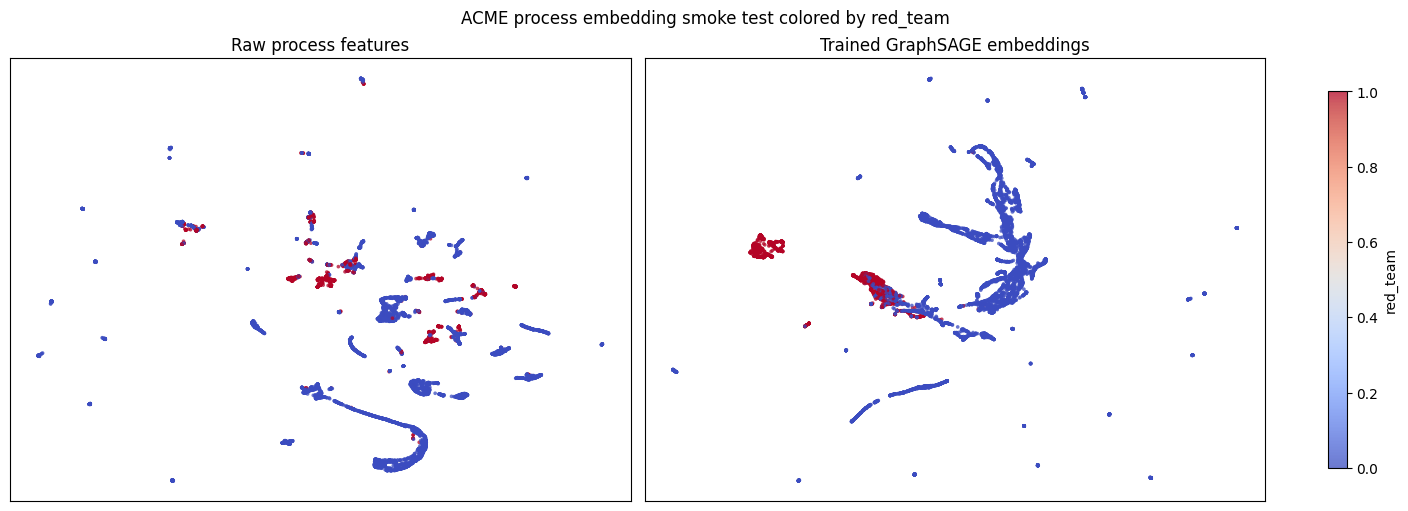

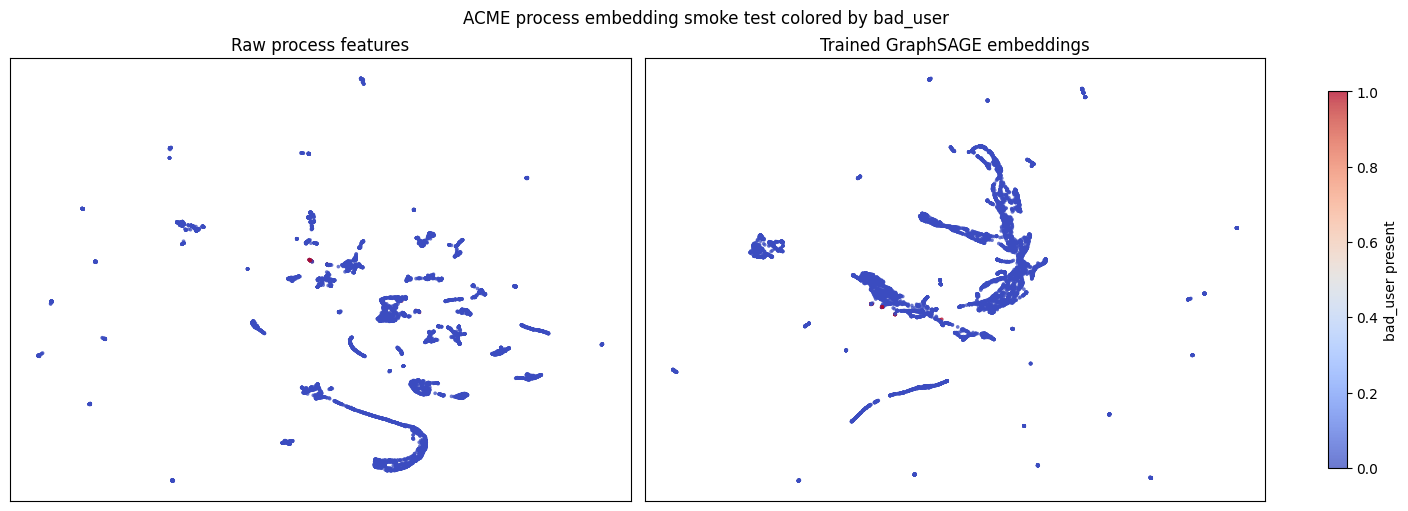

In [13]:
def fit_umap_2d(matrix, random_state=RANDOM_STATE):
    matrix = matrix.detach().cpu().numpy() if torch.is_tensor(matrix) else np.asarray(matrix)
    matrix = np.nan_to_num(matrix)
    matrix = StandardScaler().fit_transform(matrix)
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.1,
        metric="euclidean",
        random_state=random_state,
    )
    return reducer.fit_transform(matrix)


def plot_two_projections(raw_xy, sage_xy, color_values, title, colorbar_label, cmap="coolwarm", left_title="Raw process features", right_title="Trained GraphSAGE embeddings"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    for ax, xy, subtitle in [
        (axes[0], raw_xy, left_title),
        (axes[1], sage_xy, right_title),
    ]:
        scatter = ax.scatter(
            xy[:, 0],
            xy[:, 1],
            c=color_values,
            cmap=cmap,
            s=7,
            alpha=0.75,
            linewidths=0,
        )
        ax.set_title(subtitle)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(title)
    fig.colorbar(scatter, ax=axes, label=colorbar_label, shrink=0.85)
    plt.show()

raw_xy = fit_umap_2d(data["process"].x)
sage_xy = fit_umap_2d(process_embeddings)

plot_two_projections(
    raw_xy,
    sage_xy,
    process_meta["red_team"].to_numpy(),
    "ACME process embedding smoke test colored by red_team",
    "red_team",
)

plot_two_projections(
    raw_xy,
    sage_xy,
    process_meta["bad_user_binary"].to_numpy(),
    "ACME process embedding smoke test colored by bad_user",
    "bad_user present",
)


Session embeddings shape: (6736, 64)
Malicious sessions: 327 / 6736
Largest session in smoke sample: 1250


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


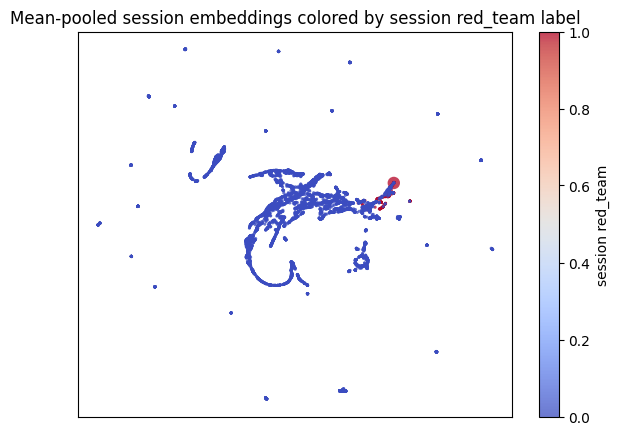

In [14]:
def mean_pool_by_session(process_embeddings, session_id, y):
    session_id = session_id.detach().cpu()
    embeddings = process_embeddings.detach().cpu()
    y = y.detach().cpu()

    n_sessions = int(session_id.max().item()) + 1 if len(session_id) else 0
    session_embeddings = torch.zeros((n_sessions, embeddings.shape[1]), dtype=embeddings.dtype)
    session_labels = torch.zeros(n_sessions, dtype=torch.long)
    session_sizes = torch.zeros(n_sessions, dtype=torch.float32)

    for sid in range(n_sessions):
        mask = session_id == sid
        session_embeddings[sid] = embeddings[mask].mean(dim=0)
        session_labels[sid] = y[mask].max()
        session_sizes[sid] = mask.sum()

    return session_embeddings, session_labels, session_sizes

session_embeddings, session_labels, session_sizes = mean_pool_by_session(
    process_embeddings,
    data["process"].session_id,
    y,
)

print(f"Session embeddings shape: {tuple(session_embeddings.shape)}")
print(f"Malicious sessions: {int(session_labels.sum())} / {len(session_labels)}")
print(f"Largest session in smoke sample: {int(session_sizes.max().item())}")

if len(session_embeddings) >= 10:
    session_xy = fit_umap_2d(session_embeddings)
    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(
        session_xy[:, 0],
        session_xy[:, 1],
        c=session_labels.numpy(),
        cmap="coolwarm",
        s=np.clip(session_sizes.numpy(), 5, 80),
        alpha=0.75,
        linewidths=0,
    )
    plt.title("Mean-pooled session embeddings colored by session red_team label")
    plt.xticks([])
    plt.yticks([])
    plt.colorbar(scatter, label="session red_team")
    plt.show()


## Unsupervised GraphSAGE Embeddings: Behavioral Edges Only

This version trains GraphSAGE without labels and reconstructs only behavioral edges (`spawns`, `touches`). `host` and `user` edges remain available for message passing, but they are not reconstruction targets. `red_team` and `bad_user` are used only after training to color the plots.


In [15]:
UNSUP_GRAPH_SAGE_EPOCHS = 40
UNSUP_EMBEDDING_DIM = 64
UNSUP_NEGATIVE_RATIO = 1


def fit_umap_2d(matrix, random_state=RANDOM_STATE):
    matrix = matrix.detach().cpu().numpy() if torch.is_tensor(matrix) else np.asarray(matrix)
    matrix = np.nan_to_num(matrix)
    matrix = StandardScaler().fit_transform(matrix)
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.1,
        metric="euclidean",
        random_state=random_state,
    )
    return reducer.fit_transform(matrix)


def plot_two_projections(raw_xy, sage_xy, color_values, title, colorbar_label, cmap="coolwarm", left_title="Raw process features", right_title="Unsupervised GraphSAGE embeddings"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    for ax, xy, subtitle in [
        (axes[0], raw_xy, left_title),
        (axes[1], sage_xy, right_title),
    ]:
        scatter = ax.scatter(
            xy[:, 0],
            xy[:, 1],
            c=color_values,
            cmap=cmap,
            s=7,
            alpha=0.75,
            linewidths=0,
        )
        ax.set_title(subtitle)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(title)
    fig.colorbar(scatter, ax=axes, label=colorbar_label, shrink=0.85)
    plt.show()


def mean_pool_by_session(process_embeddings, session_id, y):
    session_id = session_id.detach().cpu()
    embeddings = process_embeddings.detach().cpu()
    y = y.detach().cpu()

    n_sessions = int(session_id.max().item()) + 1 if len(session_id) else 0
    session_embeddings = torch.zeros((n_sessions, embeddings.shape[1]), dtype=embeddings.dtype)
    session_labels = torch.zeros(n_sessions, dtype=torch.long)
    session_sizes = torch.zeros(n_sessions, dtype=torch.float32)

    for sid in range(n_sessions):
        mask = session_id == sid
        session_embeddings[sid] = embeddings[mask].mean(dim=0)
        session_labels[sid] = y[mask].max()
        session_sizes[sid] = mask.sum()

    return session_embeddings, session_labels, session_sizes

# Train only on behavioral relations. Reverse edges, host edges, and user edges
# still participate in message passing, but they are not reconstruction targets.
UNSUP_TRAIN_RELATIONS = {
    "spawns",
    "touches",
}


def selected_edge_types_for_unsupervised_training(data):
    selected = []
    for edge_type in data.edge_types:
        src_type, relation, dst_type = edge_type
        edge_index = data[edge_type].edge_index
        if relation in UNSUP_TRAIN_RELATIONS and edge_index.numel() > 0:
            selected.append(edge_type)
    if not selected:
        raise ValueError("No non-empty edge types available for unsupervised training.")
    return selected


def sample_negative_edges(data, edge_type, num_neg, device):
    src_type, _, dst_type = edge_type
    src_nodes = data[src_type].num_nodes
    dst_nodes = data[dst_type].num_nodes
    neg_src = torch.randint(src_nodes, (num_neg,), device=device)
    neg_dst = torch.randint(dst_nodes, (num_neg,), device=device)
    return neg_src, neg_dst


def relation_dot_loss(z_dict, data, edge_type, negative_ratio=UNSUP_NEGATIVE_RATIO):
    src_type, _, dst_type = edge_type
    edge_index = data[edge_type].edge_index
    src, dst = edge_index[0], edge_index[1]

    pos_logits = (z_dict[src_type][src] * z_dict[dst_type][dst]).sum(dim=-1)

    num_neg = max(1, int(pos_logits.numel() * negative_ratio))
    neg_src, neg_dst = sample_negative_edges(data, edge_type, num_neg, pos_logits.device)
    neg_logits = (z_dict[src_type][neg_src] * z_dict[dst_type][neg_dst]).sum(dim=-1)

    logits = torch.cat([pos_logits, neg_logits])
    labels = torch.cat([torch.ones_like(pos_logits), torch.zeros_like(neg_logits)])
    return F.binary_cross_entropy_with_logits(logits, labels), pos_logits.detach(), neg_logits.detach()


def train_unsupervised_graphsage(data, epochs=UNSUP_GRAPH_SAGE_EPOCHS):
    data = data.to(DEVICE)
    train_edge_types = selected_edge_types_for_unsupervised_training(data)
    print("Behavioral reconstruction target relations:", sorted(UNSUP_TRAIN_RELATIONS))
    print("Training edge types:")
    for edge_type in train_edge_types:
        print(f"  {edge_type}: {data[edge_type].edge_index.shape[1]:,} edges")

    encoder = HeteroGraphEncoder(
        data.metadata(),
        hidden_channels=64,
        out_channels=UNSUP_EMBEDDING_DIM,
        num_layers=2,
        conv="sage",
    ).to(DEVICE)
    optimizer = torch.optim.Adam(encoder.parameters(), lr=0.01, weight_decay=1e-4)

    history = []
    for epoch in range(1, epochs + 1):
        encoder.train()
        optimizer.zero_grad()
        z_dict = encoder(data.x_dict, data.edge_index_dict)

        losses = []
        pos_means = []
        neg_means = []
        for edge_type in train_edge_types:
            loss, pos_logits, neg_logits = relation_dot_loss(z_dict, data, edge_type)
            losses.append(loss)
            pos_means.append(pos_logits.sigmoid().mean())
            neg_means.append(neg_logits.sigmoid().mean())

        total_loss = torch.stack(losses).mean()
        total_loss.backward()
        optimizer.step()

        row = {
            "epoch": epoch,
            "loss": float(total_loss.item()),
            "pos_score": float(torch.stack(pos_means).mean().item()),
            "neg_score": float(torch.stack(neg_means).mean().item()),
        }
        history.append(row)

        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(
                f"epoch={epoch:02d} loss={row['loss']:.4f} "
                f"pos_score={row['pos_score']:.3f} neg_score={row['neg_score']:.3f}"
            )

    encoder.eval()
    with torch.no_grad():
        z_dict = encoder(data.x_dict, data.edge_index_dict)
    return encoder, z_dict["process"].detach().cpu(), pd.DataFrame(history)

unsup_encoder, unsup_process_embeddings, unsup_history = train_unsupervised_graphsage(data)
unsup_history.tail()


Behavioral reconstruction target relations: ['spawns', 'touches']
Training edge types:
  ('process', 'spawns', 'process'): 1,494 edges
  ('process', 'touches', 'file'): 255 edges
epoch=01 loss=45.0496 pos_score=0.925 neg_score=0.776
epoch=05 loss=0.7139 pos_score=0.688 neg_score=0.615
epoch=10 loss=0.6730 pos_score=0.614 neg_score=0.520
epoch=15 loss=0.6328 pos_score=0.634 neg_score=0.521
epoch=20 loss=0.6185 pos_score=0.644 neg_score=0.501
epoch=25 loss=0.6154 pos_score=0.699 neg_score=0.553
epoch=30 loss=0.6189 pos_score=0.657 neg_score=0.509
epoch=35 loss=0.6070 pos_score=0.648 neg_score=0.502
epoch=40 loss=0.5914 pos_score=0.688 neg_score=0.520


,epoch,loss,pos_score,neg_score
35,36,0.603403,0.642969,0.489589
36,37,0.597659,0.650990,0.493657
37,38,0.587818,0.668208,0.500888
38,39,0.600934,0.684484,0.527803
39,40,0.591398,0.687655,0.520264


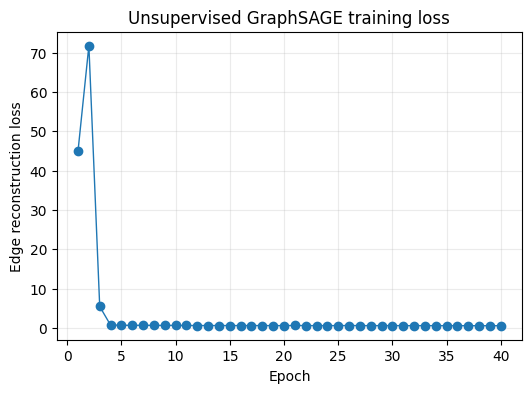

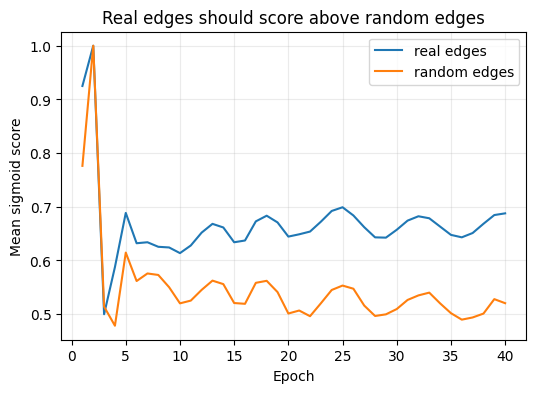

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(unsup_history["epoch"], unsup_history["loss"], marker="o", linewidth=1)
plt.xlabel("Epoch")
plt.ylabel("Edge reconstruction loss")
plt.title("Unsupervised GraphSAGE training loss")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(unsup_history["epoch"], unsup_history["pos_score"], label="real edges")
plt.plot(unsup_history["epoch"], unsup_history["neg_score"], label="random edges")
plt.xlabel("Epoch")
plt.ylabel("Mean sigmoid score")
plt.title("Real edges should score above random edges")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


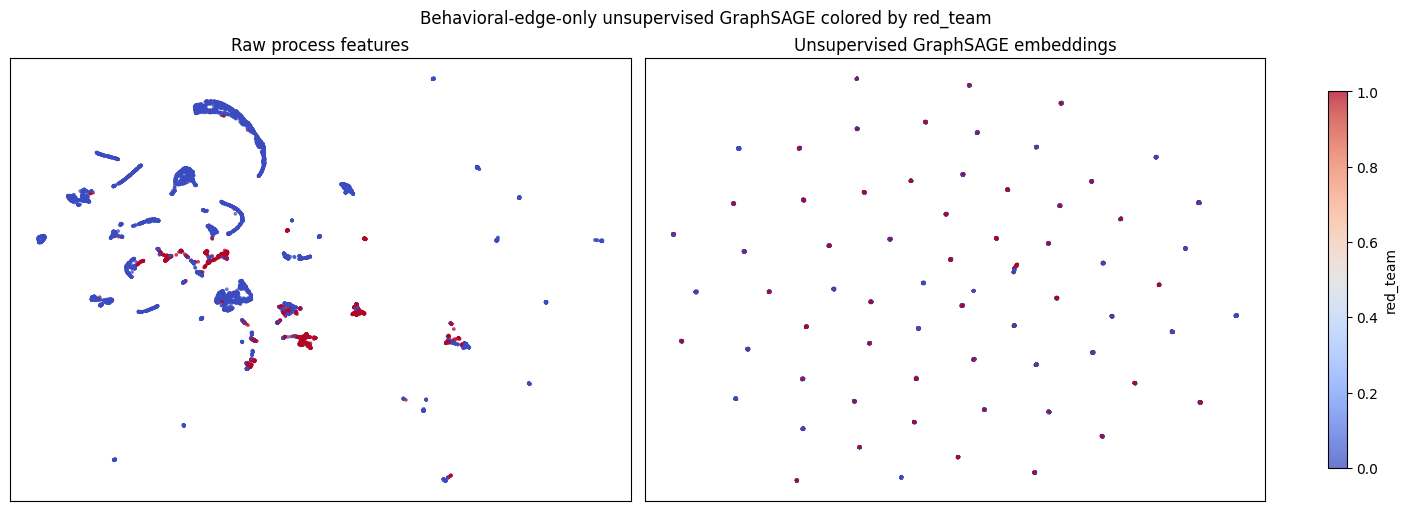

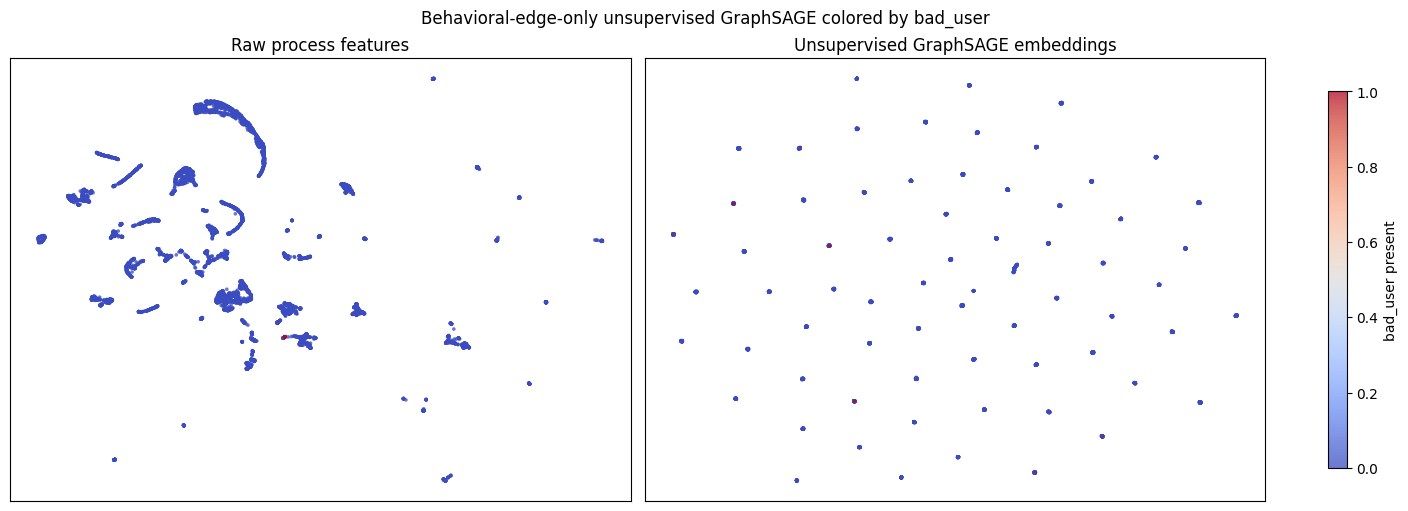

In [17]:
raw_xy = fit_umap_2d(data["process"].x)
unsup_sage_xy = fit_umap_2d(unsup_process_embeddings)

plot_two_projections(
    raw_xy,
    unsup_sage_xy,
    process_meta["red_team"].to_numpy(),
    "Behavioral-edge-only unsupervised GraphSAGE colored by red_team",
    "red_team",
)

plot_two_projections(
    raw_xy,
    unsup_sage_xy,
    process_meta["bad_user_binary"].to_numpy(),
    "Behavioral-edge-only unsupervised GraphSAGE colored by bad_user",
    "bad_user present",
)


Unsupervised session embeddings shape: (6736, 64)
Malicious sessions for coloring only: 327 / 6736


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


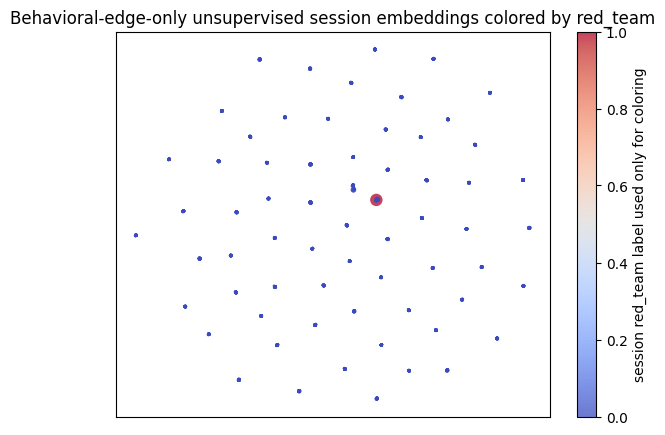

In [18]:
unsup_session_embeddings, unsup_session_labels, unsup_session_sizes = mean_pool_by_session(
    unsup_process_embeddings,
    data["process"].session_id.cpu(),
    data["process"].y.cpu(),
)

print(f"Unsupervised session embeddings shape: {tuple(unsup_session_embeddings.shape)}")
print(f"Malicious sessions for coloring only: {int(unsup_session_labels.sum())} / {len(unsup_session_labels)}")

if len(unsup_session_embeddings) >= 10:
    unsup_session_xy = fit_umap_2d(unsup_session_embeddings)
    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(
        unsup_session_xy[:, 0],
        unsup_session_xy[:, 1],
        c=unsup_session_labels.numpy(),
        cmap="coolwarm",
        s=np.clip(unsup_session_sizes.numpy(), 5, 80),
        alpha=0.75,
        linewidths=0,
    )
    plt.title("Behavioral-edge-only unsupervised session embeddings colored by red_team")
    plt.xticks([])
    plt.yticks([])
    plt.colorbar(scatter, label="session red_team label used only for coloring")
    plt.show()


## Unsupervised GraphSAGE + Process Feature Reconstruction

This version still uses no labels. It trains on behavioral graph structure (`spawns`, `touches`) while also forcing the process embedding to reconstruct `data["process"].x`. Message passing is restricted to behavioral relations so host/user edges cannot dominate the embedding.


In [19]:
FEATURE_RECON_EPOCHS = 40
FEATURE_RECON_EMBEDDING_DIM = 64
FEATURE_RECON_ALPHA = 0.5
FEATURE_RECON_NEGATIVE_RATIO = 1

BEHAVIORAL_MESSAGE_RELATIONS = {
    "spawns",
    "spawned_by",
    "touches",
    "touched_by",
}

BEHAVIORAL_RECON_TARGET_RELATIONS = {
    "spawns",
    "touches",
}


def behavioral_edge_index_dict(data):
    edge_index_dict = {}
    for edge_type, edge_index in data.edge_index_dict.items():
        if edge_type[1] in BEHAVIORAL_MESSAGE_RELATIONS and edge_index.numel() > 0:
            edge_index_dict[edge_type] = edge_index
    if not edge_index_dict:
        raise ValueError("No behavioral message-passing edges found.")
    return edge_index_dict


def behavioral_reconstruction_edge_types(data):
    selected = []
    for edge_type in data.edge_types:
        if edge_type[1] in BEHAVIORAL_RECON_TARGET_RELATIONS and data[edge_type].edge_index.numel() > 0:
            selected.append(edge_type)
    if not selected:
        raise ValueError("No behavioral reconstruction target edges found.")
    return selected


def relation_dot_loss_with_ratio(z_dict, data, edge_type, negative_ratio=FEATURE_RECON_NEGATIVE_RATIO):
    src_type, _, dst_type = edge_type
    edge_index = data[edge_type].edge_index
    src, dst = edge_index[0], edge_index[1]

    pos_logits = (z_dict[src_type][src] * z_dict[dst_type][dst]).sum(dim=-1)

    num_neg = max(1, int(pos_logits.numel() * negative_ratio))
    neg_src = torch.randint(data[src_type].num_nodes, (num_neg,), device=pos_logits.device)
    neg_dst = torch.randint(data[dst_type].num_nodes, (num_neg,), device=pos_logits.device)
    neg_logits = (z_dict[src_type][neg_src] * z_dict[dst_type][neg_dst]).sum(dim=-1)

    logits = torch.cat([pos_logits, neg_logits])
    labels = torch.cat([torch.ones_like(pos_logits), torch.zeros_like(neg_logits)])
    loss = F.binary_cross_entropy_with_logits(logits, labels)
    return loss, pos_logits.detach(), neg_logits.detach()


class GraphSAGEFeatureAutoencoder(nn.Module):
    def __init__(self, metadata, process_feature_dim, embedding_dim=FEATURE_RECON_EMBEDDING_DIM):
        super().__init__()
        self.encoder = HeteroGraphEncoder(
            metadata,
            hidden_channels=64,
            out_channels=embedding_dim,
            num_layers=2,
            conv="sage",
        )
        self.process_decoder = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.ReLU(),
            nn.Linear(64, process_feature_dim),
        )

    def forward(self, x_dict, edge_index_dict):
        z_dict = self.encoder(x_dict, edge_index_dict)
        process_recon = self.process_decoder(z_dict["process"])
        return z_dict, process_recon


def train_graphsage_feature_autoencoder(data, epochs=FEATURE_RECON_EPOCHS):
    data = data.to(DEVICE)
    msg_edge_index_dict = behavioral_edge_index_dict(data)
    recon_edge_types = behavioral_reconstruction_edge_types(data)

    print("Behavioral message-passing edge types:")
    for edge_type, edge_index in msg_edge_index_dict.items():
        print(f"  {edge_type}: {edge_index.shape[1]:,} edges")
    print("Behavioral reconstruction target edge types:")
    for edge_type in recon_edge_types:
        print(f"  {edge_type}: {data[edge_type].edge_index.shape[1]:,} edges")

    model = GraphSAGEFeatureAutoencoder(
        data.metadata(),
        process_feature_dim=data["process"].x.shape[1],
    ).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        z_dict, process_recon = model(data.x_dict, msg_edge_index_dict)

        edge_losses = []
        pos_means = []
        neg_means = []
        for edge_type in recon_edge_types:
            edge_loss, pos_logits, neg_logits = relation_dot_loss_with_ratio(z_dict, data, edge_type)
            edge_losses.append(edge_loss)
            pos_means.append(pos_logits.sigmoid().mean())
            neg_means.append(neg_logits.sigmoid().mean())

        edge_loss = torch.stack(edge_losses).mean()
        feature_loss = F.mse_loss(process_recon, data["process"].x)
        total_loss = edge_loss + FEATURE_RECON_ALPHA * feature_loss
        total_loss.backward()
        optimizer.step()

        row = {
            "epoch": epoch,
            "loss": float(total_loss.item()),
            "edge_loss": float(edge_loss.item()),
            "feature_loss": float(feature_loss.item()),
            "pos_score": float(torch.stack(pos_means).mean().item()),
            "neg_score": float(torch.stack(neg_means).mean().item()),
        }
        history.append(row)

        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(
                f"epoch={epoch:02d} loss={row['loss']:.4f} "
                f"edge={row['edge_loss']:.4f} feature={row['feature_loss']:.4f} "
                f"pos={row['pos_score']:.3f} neg={row['neg_score']:.3f}"
            )

    model.eval()
    with torch.no_grad():
        z_dict, process_recon = model(data.x_dict, msg_edge_index_dict)
    return model, z_dict["process"].detach().cpu(), process_recon.detach().cpu(), pd.DataFrame(history)

feature_autoencoder, feature_process_embeddings, feature_process_recon, feature_history = train_graphsage_feature_autoencoder(data)
feature_history.tail()


Behavioral message-passing edge types:
  ('process', 'spawns', 'process'): 1,494 edges
  ('process', 'spawned_by', 'process'): 1,494 edges
  ('process', 'touches', 'file'): 255 edges
  ('file', 'touched_by', 'process'): 255 edges
Behavioral reconstruction target edge types:
  ('process', 'spawns', 'process'): 1,494 edges
  ('process', 'touches', 'file'): 255 edges
epoch=01 loss=2.6760 edge=2.2323 feature=0.8874 pos=0.795 neg=0.686
epoch=05 loss=0.9044 edge=0.4888 feature=0.8312 pos=0.925 neg=0.438
epoch=10 loss=0.7267 edge=0.3945 feature=0.6643 pos=0.932 neg=0.351
epoch=15 loss=0.6220 edge=0.3296 feature=0.5847 pos=0.884 neg=0.309
epoch=20 loss=0.6262 edge=0.3428 feature=0.5668 pos=0.923 neg=0.313
epoch=25 loss=0.5900 edge=0.3417 feature=0.4967 pos=0.963 neg=0.309
epoch=30 loss=0.5745 edge=0.3583 feature=0.4324 pos=0.964 neg=0.308
epoch=35 loss=0.4943 edge=0.2977 feature=0.3932 pos=0.966 neg=0.294
epoch=40 loss=0.4304 edge=0.2472 feature=0.3664 pos=0.943 neg=0.285


,epoch,loss,edge_loss,feature_loss,pos_score,neg_score
35,36,0.506018,0.311388,0.389259,0.964927,0.301641
36,37,0.492771,0.300197,0.385148,0.963217,0.296380
37,38,0.485485,0.295232,0.380507,0.961976,0.289620
38,39,0.493044,0.306030,0.374027,0.960310,0.298049
39,40,0.430417,0.247234,0.366365,0.943212,0.285135


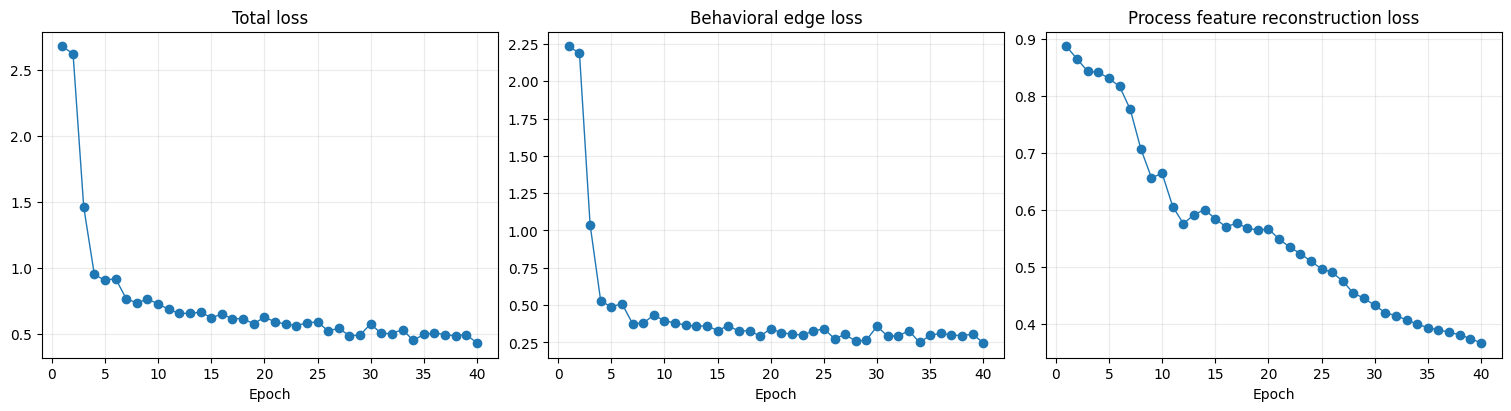

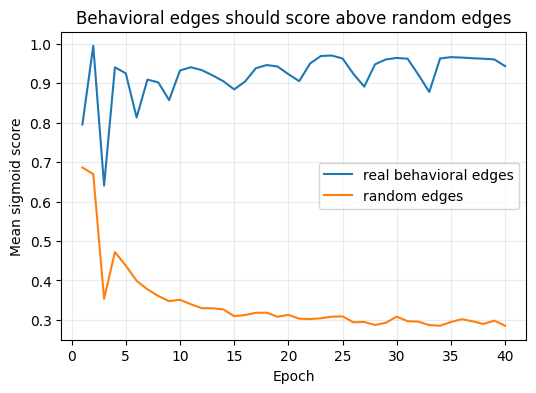

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
axes[0].plot(feature_history["epoch"], feature_history["loss"], marker="o", linewidth=1)
axes[0].set_title("Total loss")
axes[1].plot(feature_history["epoch"], feature_history["edge_loss"], marker="o", linewidth=1)
axes[1].set_title("Behavioral edge loss")
axes[2].plot(feature_history["epoch"], feature_history["feature_loss"], marker="o", linewidth=1)
axes[2].set_title("Process feature reconstruction loss")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(feature_history["epoch"], feature_history["pos_score"], label="real behavioral edges")
plt.plot(feature_history["epoch"], feature_history["neg_score"], label="random edges")
plt.xlabel("Epoch")
plt.ylabel("Mean sigmoid score")
plt.title("Behavioral edges should score above random edges")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


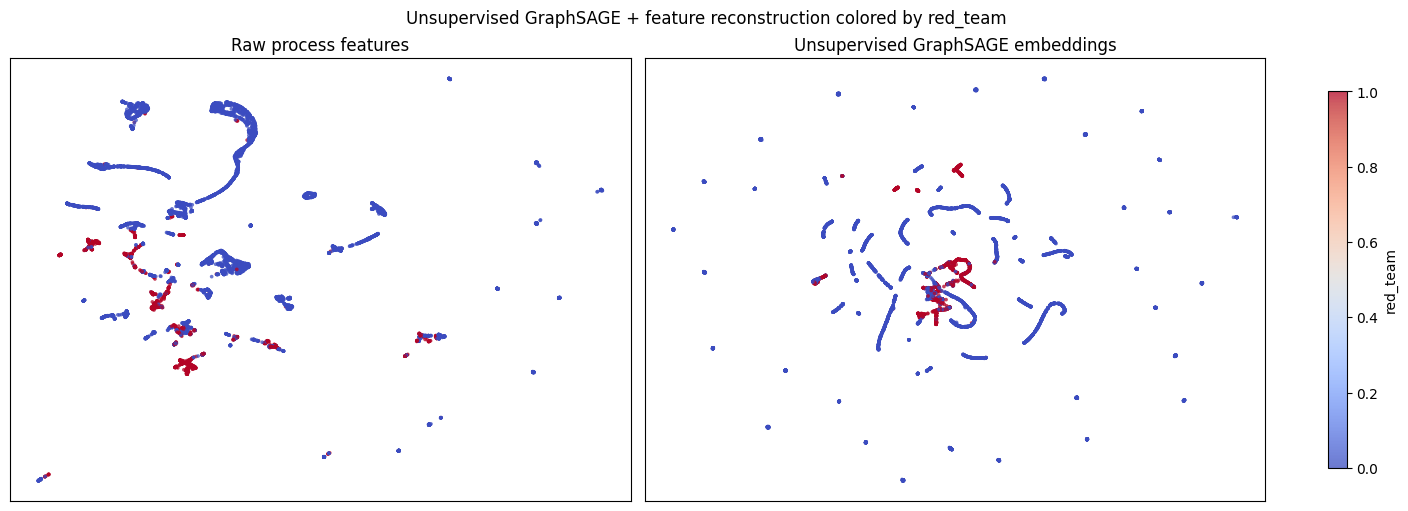

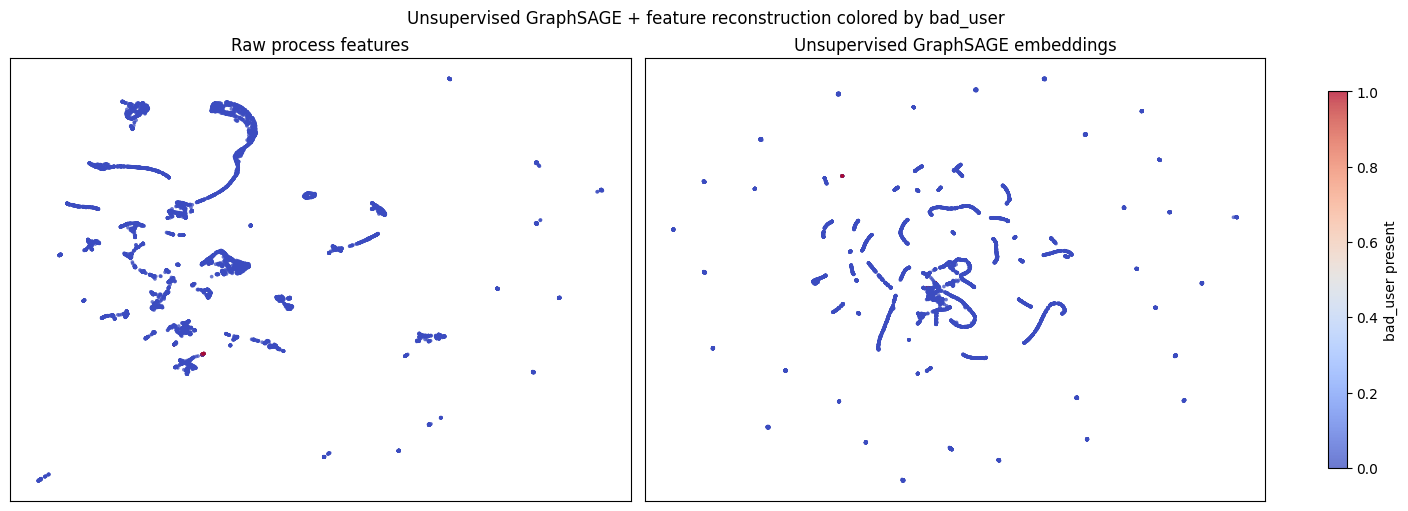

In [21]:
raw_xy = fit_umap_2d(data["process"].x)
feature_sage_xy = fit_umap_2d(feature_process_embeddings)

plot_two_projections(
    raw_xy,
    feature_sage_xy,
    process_meta["red_team"].to_numpy(),
    "Unsupervised GraphSAGE + feature reconstruction colored by red_team",
    "red_team",
)

plot_two_projections(
    raw_xy,
    feature_sage_xy,
    process_meta["bad_user_binary"].to_numpy(),
    "Unsupervised GraphSAGE + feature reconstruction colored by bad_user",
    "bad_user present",
)


Feature-anchored session embeddings shape: (6736, 64)
Malicious sessions for coloring only: 327 / 6736


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


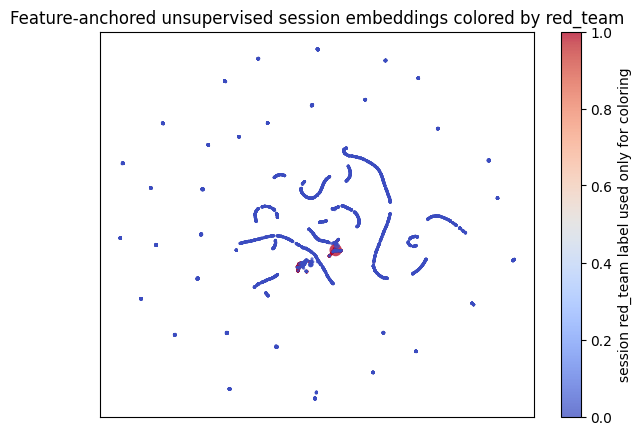

In [22]:
feature_session_embeddings, feature_session_labels, feature_session_sizes = mean_pool_by_session(
    feature_process_embeddings,
    data["process"].session_id.cpu(),
    data["process"].y.cpu(),
)

print(f"Feature-anchored session embeddings shape: {tuple(feature_session_embeddings.shape)}")
print(f"Malicious sessions for coloring only: {int(feature_session_labels.sum())} / {len(feature_session_labels)}")

if len(feature_session_embeddings) >= 10:
    feature_session_xy = fit_umap_2d(feature_session_embeddings)
    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(
        feature_session_xy[:, 0],
        feature_session_xy[:, 1],
        c=feature_session_labels.numpy(),
        cmap="coolwarm",
        s=np.clip(feature_session_sizes.numpy(), 5, 80),
        alpha=0.75,
        linewidths=0,
    )
    plt.title("Feature-anchored unsupervised session embeddings colored by red_team")
    plt.xticks([])
    plt.yticks([])
    plt.colorbar(scatter, label="session red_team label used only for coloring")
    plt.show()


In [23]:
process_meta["red_team"].to_numpy()

array([1, 1, 1, ..., 1, 0, 1], shape=(8329,))

## Semantic Raw Feature Baseline

This label-free baseline enriches numeric process counters with `process_name`, command-line `args`, process path, filename/rare-file tokens, and a derived ancestor path. It is not a GNN; it is the stronger raw-feature baseline we compare graph embeddings against.


In [24]:
from sklearn.decomposition import TruncatedSVD
from semantic_feature_baseline import SemanticProcessFeatureBuilder, SemanticFeatureConfig

SEMANTIC_MAX_TEXT_FEATURES = 20_000
SEMANTIC_SVD_COMPONENTS = 64

semantic_builder = SemanticProcessFeatureBuilder(
    SemanticFeatureConfig(
        max_text_features=SEMANTIC_MAX_TEXT_FEATURES,
        min_df=2,
        rare_file_max_degree=20,
        ngram_range=(1, 2),
    )
)

semantic_process_features = semantic_builder.fit_transform(
    acme_sample,
    process_ids=data["process"].external_id,
)

print(f"Semantic feature matrix shape: {semantic_process_features.shape}")
print(f"Semantic feature matrix nnz: {semantic_process_features.nnz:,}")
print("First semantic feature names:")
print(semantic_builder.feature_names_[:20])

semantic_svd = TruncatedSVD(
    n_components=min(SEMANTIC_SVD_COMPONENTS, semantic_process_features.shape[1] - 1),
    random_state=RANDOM_STATE,
)
semantic_process_svd = semantic_svd.fit_transform(semantic_process_features)
print(f"Semantic SVD embedding shape: {semantic_process_svd.shape}")
print(f"Explained variance ratio sum: {semantic_svd.explained_variance_ratio_.sum():.3f}")


Semantic feature matrix shape: (8329, 7476)
Semantic feature matrix nnz: 304,739
First semantic feature names:
['num:duration_seconds', 'num:cpu_cycle_count', 'num:cpu_utilization', 'num:commit_charge', 'num:commit_peak', 'num:read_operation_count', 'num:write_operation_count', 'num:read_transfer_kilobytes', 'num:write_transfer_kilobytes', 'num:hard_fault_count', 'num:reg_totals', 'num:reg_reads', 'num:reg_writes', 'num:reg_createkeys', 'num:reg_deletekeys', 'num:reg_deletevalues', 'num:Close_Events', 'num:Create_Events', 'num:Delete_Events', 'num:Rename_Events']
Semantic SVD embedding shape: (8329, 64)
Explained variance ratio sum: 0.996


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


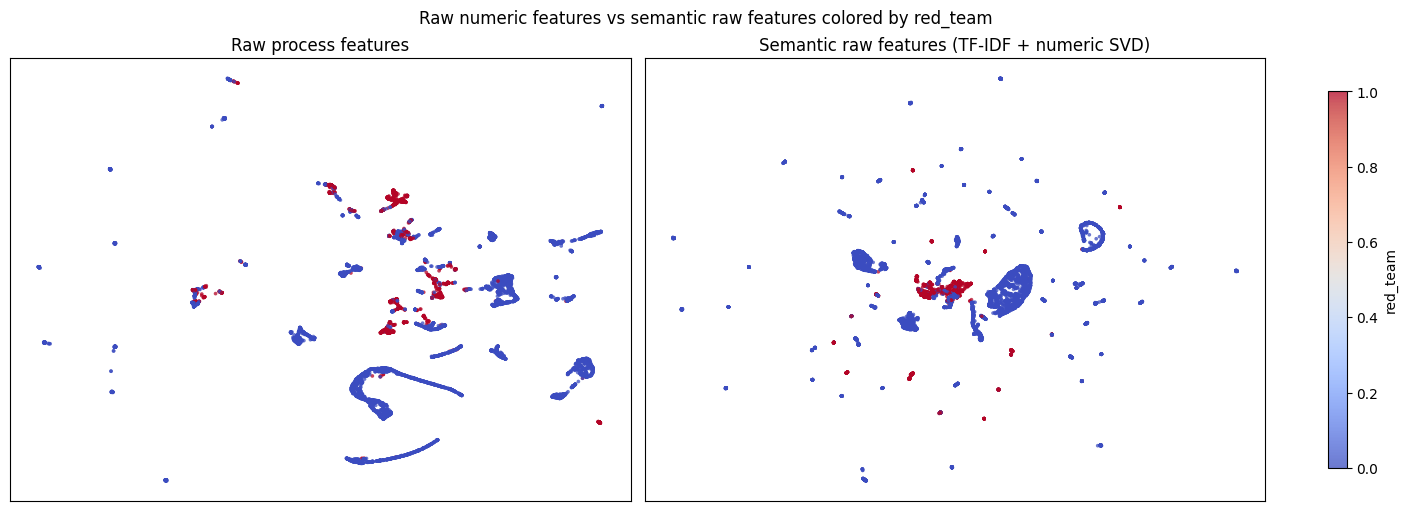

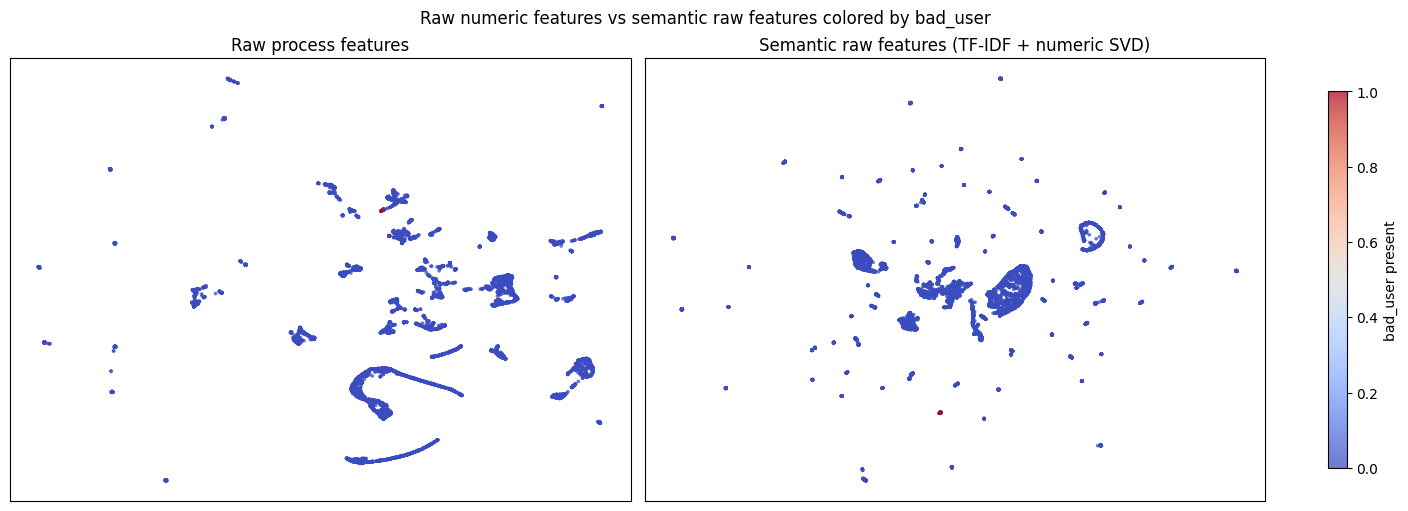

In [25]:
raw_xy = fit_umap_2d(data["process"].x)
semantic_xy = fit_umap_2d(semantic_process_svd)

def plot_semantic_feature_comparison(color_values, title, colorbar_label, cmap="coolwarm"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    for ax, xy, subtitle in [
        (axes[0], raw_xy, "Raw process features"),
        (axes[1], semantic_xy, "Semantic raw features (TF-IDF + numeric SVD)"),
    ]:
        scatter = ax.scatter(
            xy[:, 0],
            xy[:, 1],
            c=color_values,
            cmap=cmap,
            s=7,
            alpha=0.75,
            linewidths=0,
        )
        ax.set_title(subtitle)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(title)
    fig.colorbar(scatter, ax=axes, label=colorbar_label, shrink=0.85)
    plt.show()


plot_semantic_feature_comparison(
    process_meta["red_team"].to_numpy(),
    "Raw numeric features vs semantic raw features colored by red_team",
    "red_team",
)

plot_semantic_feature_comparison(
    process_meta["bad_user_binary"].to_numpy(),
    "Raw numeric features vs semantic raw features colored by bad_user",
    "bad_user present",
)


## Semantic Ablation and Semantic-Feature GraphSAGE

This section checks whether the signal is coming from numeric counters, semantic/text tokens, or the graph. The GraphSAGE run below is supervised like the first smoke test; it only changes `data["process"].x` from numeric counters to `semantic_raw_svd`.


In [26]:
SEMANTIC_TEXT_MAX_FEATURES = SEMANTIC_MAX_TEXT_FEATURES

semantic_text_builder = SemanticProcessFeatureBuilder(
    SemanticFeatureConfig(
        max_text_features=SEMANTIC_TEXT_MAX_FEATURES,
        min_df=2,
        rare_file_max_degree=20,
        ngram_range=(1, 2),
        include_numeric=False,
    )
)

semantic_text_features = semantic_text_builder.fit_transform(
    acme_sample,
    process_ids=data["process"].external_id,
)

semantic_text_svd = TruncatedSVD(
    n_components=min(SEMANTIC_SVD_COMPONENTS, semantic_text_features.shape[1] - 1),
    random_state=RANDOM_STATE,
).fit_transform(semantic_text_features)

print(f"Text-only semantic feature matrix shape: {semantic_text_features.shape}")
print(f"Text-only semantic feature matrix nnz: {semantic_text_features.nnz:,}")
print(f"Text-only semantic SVD shape: {semantic_text_svd.shape}")
print("First text-only semantic feature names:")
print(semantic_text_builder.feature_names_[:20])


Text-only semantic feature matrix shape: (8329, 7434)
Text-only semantic feature matrix nnz: 223,739
Text-only semantic SVD shape: (8329, 64)
First text-only semantic feature names:
['text:ancestor=akagi64.exe', 'text:ancestor=akagi64.exe ancestor=wusa.exe', 'text:ancestor=arp.exe', 'text:ancestor=attrib.exe', 'text:ancestor=auditpol.exe', 'text:ancestor=backgroundtaskhost.exe', 'text:ancestor=bcdedit.exe', 'text:ancestor=calc.exe', 'text:ancestor=calc.exe ancestor=win32calc.exe', 'text:ancestor=certutil.exe', 'text:ancestor=chrome.exe', 'text:ancestor=cleanmgr.exe', 'text:ancestor=cleanmgr.exe ancestor=dismhost.exe', 'text:ancestor=clip.exe', 'text:ancestor=cmd.exe', 'text:ancestor=cmd.exe ancestor=attrib.exe', 'text:ancestor=cmd.exe ancestor=auditpol.exe', 'text:ancestor=cmd.exe ancestor=bcdedit.exe', 'text:ancestor=cmd.exe ancestor=certutil.exe', 'text:ancestor=cmd.exe ancestor=clip.exe']


In [27]:
SEMANTIC_GRAPH_SAGE_EPOCHS = GRAPH_SAGE_EPOCHS

if "ProcessGraphSAGESmokeModel" not in globals():
    raise RuntimeError("Run the supervised GraphSAGE smoke-test model cell before this semantic GraphSAGE ablation.")

semantic_graph_data = data.clone().to(DEVICE)
semantic_graph_x = StandardScaler().fit_transform(np.nan_to_num(semantic_process_svd)).astype(np.float32)
semantic_graph_data["process"].x = torch.as_tensor(semantic_graph_x, dtype=torch.float32, device=DEVICE)

semantic_y = semantic_graph_data["process"].y.to(DEVICE).long()
if "train_mask" in globals() and len(train_mask) == len(semantic_y):
    semantic_train_mask = train_mask.to(DEVICE)
    semantic_val_mask = val_mask.to(DEVICE)
    semantic_test_mask = test_mask.to(DEVICE)
else:
    semantic_train_mask, semantic_val_mask, semantic_test_mask = [
        mask.to(DEVICE) for mask in make_stratified_masks(semantic_y)
    ]

semantic_graphsage_model = ProcessGraphSAGESmokeModel(
    semantic_graph_data.metadata(),
    embedding_dim=64,
).to(DEVICE)
semantic_graphsage_optimizer = torch.optim.Adam(
    semantic_graphsage_model.parameters(),
    lr=0.01,
    weight_decay=1e-4,
)

semantic_class_counts = torch.bincount(semantic_y[semantic_train_mask], minlength=2).float().clamp(min=1)
semantic_class_weights = semantic_class_counts.sum() / semantic_class_counts
semantic_class_weights = (semantic_class_weights / semantic_class_weights.mean()).to(DEVICE)

semantic_graphsage_history = []
for epoch in range(1, SEMANTIC_GRAPH_SAGE_EPOCHS + 1):
    semantic_graphsage_model.train()
    semantic_graphsage_optimizer.zero_grad()
    semantic_graphsage_logits, semantic_graphsage_embeddings = semantic_graphsage_model(
        semantic_graph_data.x_dict,
        semantic_graph_data.edge_index_dict,
    )
    semantic_loss = F.cross_entropy(
        semantic_graphsage_logits[semantic_train_mask],
        semantic_y[semantic_train_mask],
        weight=semantic_class_weights,
    )
    semantic_loss.backward()
    semantic_graphsage_optimizer.step()

    semantic_graphsage_model.eval()
    with torch.no_grad():
        semantic_graphsage_logits, semantic_graphsage_embeddings = semantic_graphsage_model(
            semantic_graph_data.x_dict,
            semantic_graph_data.edge_index_dict,
        )
        semantic_train_acc = accuracy(semantic_graphsage_logits, semantic_y, semantic_train_mask)
        semantic_val_acc = accuracy(semantic_graphsage_logits, semantic_y, semantic_val_mask)
        semantic_graphsage_history.append(
            {
                "epoch": epoch,
                "loss": float(semantic_loss.item()),
                "train_acc": semantic_train_acc,
                "val_acc": semantic_val_acc,
            }
        )

    if epoch == 1 or epoch % 5 == 0 or epoch == SEMANTIC_GRAPH_SAGE_EPOCHS:
        print(
            f"epoch={epoch:02d} loss={semantic_loss.item():.4f} "
            f"train_acc={semantic_train_acc:.3f} val_acc={semantic_val_acc:.3f}"
        )

semantic_graphsage_model.eval()
with torch.no_grad():
    semantic_graphsage_logits, semantic_graphsage_embeddings = semantic_graphsage_model(
        semantic_graph_data.x_dict,
        semantic_graph_data.edge_index_dict,
    )

print(f"Semantic GraphSAGE logits shape: {tuple(semantic_graphsage_logits.shape)}")
print(f"Semantic GraphSAGE embedding shape: {tuple(semantic_graphsage_embeddings.shape)}")


epoch=01 loss=1.1047 train_acc=0.793 val_acc=0.793
epoch=05 loss=0.1626 train_acc=0.952 val_acc=0.954
epoch=10 loss=0.0494 train_acc=0.985 val_acc=0.985
epoch=15 loss=0.0380 train_acc=0.987 val_acc=0.984
epoch=20 loss=0.0189 train_acc=0.993 val_acc=0.990
epoch=25 loss=0.0130 train_acc=0.996 val_acc=0.993
Semantic GraphSAGE logits shape: (8329, 2)
Semantic GraphSAGE embedding shape: (8329, 64)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


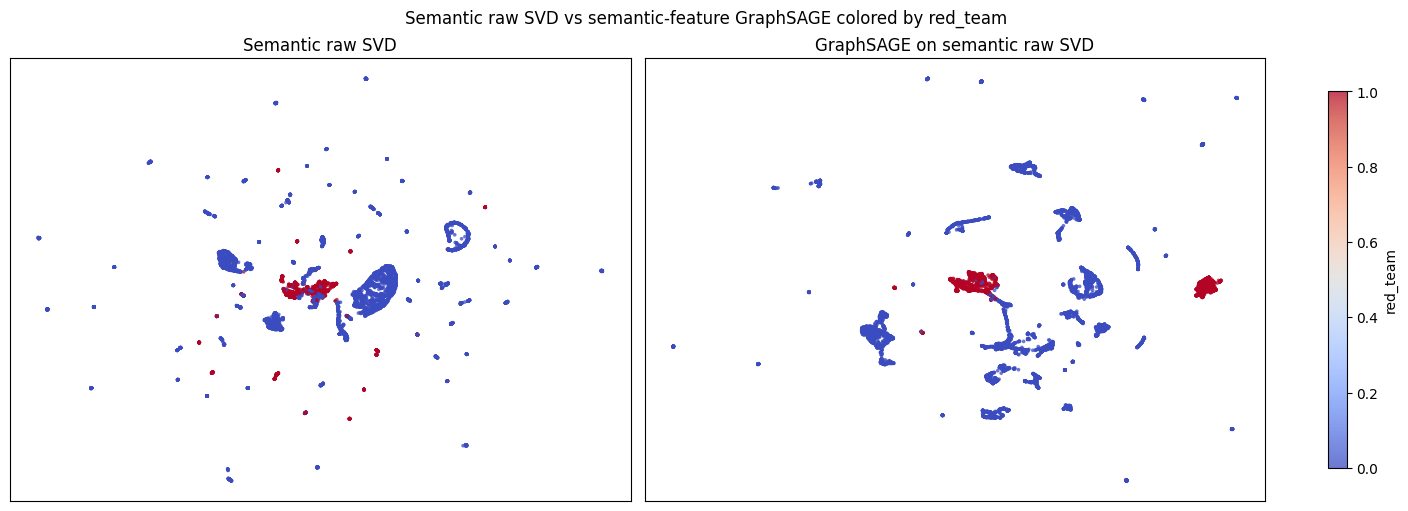

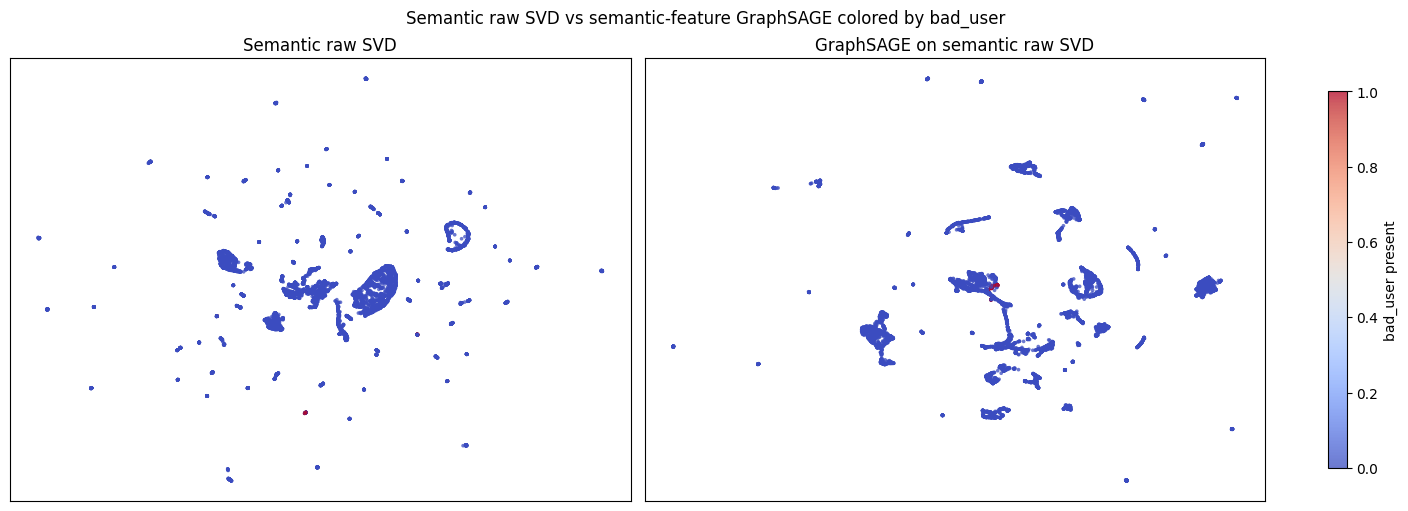

In [28]:
semantic_graphsage_xy = fit_umap_2d(semantic_graphsage_embeddings)


def plot_semantic_graphsage_comparison(color_values, title, colorbar_label, cmap="coolwarm"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    for ax, xy, subtitle in [
        (axes[0], semantic_xy, "Semantic raw SVD"),
        (axes[1], semantic_graphsage_xy, "GraphSAGE on semantic raw SVD"),
    ]:
        scatter = ax.scatter(
            xy[:, 0],
            xy[:, 1],
            c=color_values,
            cmap=cmap,
            s=7,
            alpha=0.75,
            linewidths=0,
        )
        ax.set_title(subtitle)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(title)
    fig.colorbar(scatter, ax=axes, label=colorbar_label, shrink=0.85)
    plt.show()


plot_semantic_graphsage_comparison(
    process_meta["red_team"].to_numpy(),
    "Semantic raw SVD vs semantic-feature GraphSAGE colored by red_team",
    "red_team",
)

plot_semantic_graphsage_comparison(
    process_meta["bad_user_binary"].to_numpy(),
    "Semantic raw SVD vs semantic-feature GraphSAGE colored by bad_user",
    "bad_user present",
)


## kNN Embedding Enrichment Check

This compares numeric raw features, semantic raw features, and any trained process-embedding variables currently in memory. Labels are used only for evaluation, not training.


In [ ]:
from sklearn.neighbors import NearestNeighbors
from scipy import sparse


def as_numpy_matrix(matrix):
    if torch.is_tensor(matrix):
        matrix = matrix.detach().cpu().numpy()
    if sparse.issparse(matrix):
        return StandardScaler(with_mean=False).fit_transform(matrix)
    matrix = np.asarray(matrix)
    matrix = np.nan_to_num(matrix)
    return StandardScaler().fit_transform(matrix)


def kneighbors_without_self(nn, X, k):
    k_eff = min(k, X.shape[0] - 1)
    n_query_neighbors = min(k_eff + 2, X.shape[0])
    distances, indices = nn.kneighbors(X, n_neighbors=n_query_neighbors)
    neighbor_rows = []
    distance_rows = []
    for row_idx, (idx_row, dist_row) in enumerate(zip(indices, distances)):
        keep_mask = idx_row != row_idx
        kept_indices = idx_row[keep_mask][:k_eff]
        kept_distances = dist_row[keep_mask][:k_eff]
        neighbor_rows.append(kept_indices)
        distance_rows.append(kept_distances)
    return np.vstack(neighbor_rows), np.vstack(distance_rows)


def knn_label_enrichment(matrix, labels, embedding_name, label_name, k=15):
    X = as_numpy_matrix(matrix)
    y = np.asarray(labels).astype(int)
    if X.shape[0] != len(y):
        raise ValueError(f"{embedding_name}: embedding rows ({X.shape[0]}) != label rows ({len(y)})")
    if X.shape[0] <= 1:
        raise ValueError(f"{embedding_name}: need at least 2 rows for kNN")

    nn = NearestNeighbors(metric="euclidean")
    nn.fit(X)
    neighbor_indices, _ = kneighbors_without_self(nn, X, k)

    positive_mask = y == 1
    baseline_rate = float(y.mean())
    all_neighbor_rate = float(y[neighbor_indices].mean()) if neighbor_indices.size else np.nan
    positive_neighbor_rate = (
        float(y[neighbor_indices[positive_mask]].mean())
        if positive_mask.any() and neighbor_indices.size
        else np.nan
    )
    lift = positive_neighbor_rate / baseline_rate if baseline_rate > 0 else np.nan

    return {
        "embedding": embedding_name,
        "label": label_name,
        "k": neighbor_indices.shape[1],
        "rows": X.shape[0],
        "positive_rows": int(positive_mask.sum()),
        "baseline_positive_rate": baseline_rate,
        "all_point_neighbor_positive_rate": all_neighbor_rate,
        "positive_point_neighbor_positive_rate": positive_neighbor_rate,
        "positive_neighbor_lift_vs_baseline": lift,
    }


embedding_sources = {
    "raw_process_x": data["process"].x,
}

optional_embedding_variables = {
    "semantic_features": "semantic_process_features",
    "semantic_raw_svd": "semantic_process_svd",
    "semantic_text_features": "semantic_text_features",
    "semantic_text_svd": "semantic_text_svd",
    "supervised_graphsage_semantic_x": "semantic_graphsage_embeddings",
    "supervised_graphsage": "process_embeddings",
    "unsupervised_behavioral_edges": "unsup_process_embeddings",
    "unsupervised_feature_reconstruction": "feature_process_embeddings",
}

for embedding_name, variable_name in optional_embedding_variables.items():
    if variable_name in globals():
        embedding_sources[embedding_name] = globals()[variable_name]
    else:
        print(f"Skipping {embedding_name}: run the cell that creates `{variable_name}` first.")

label_sources = {
    "red_team": process_meta["red_team"].to_numpy(),
    "bad_user": process_meta["bad_user_binary"].to_numpy(),
}

knn_rows = []
for embedding_name, matrix in embedding_sources.items():
    for label_name, labels in label_sources.items():
        knn_rows.append(knn_label_enrichment(matrix, labels, embedding_name, label_name, k=15))

knn_results = pd.DataFrame(knn_rows)
knn_results = knn_results.sort_values(
    ["label", "positive_neighbor_lift_vs_baseline"],
    ascending=[True, False],
).reset_index(drop=True)
knn_results


## kNN Neighborhood Contamination Check

This companion metric asks whether benign/negative points are polluted by positive neighbors. Good analyst maps should have high positive-near-positive concentration and low negative-near-positive contamination. The semantic raw baseline should be judged here before adding more graph model complexity.


In [ ]:
def knn_contamination_report(matrix, labels, embedding_name, label_name, k=15):
    X = as_numpy_matrix(matrix)
    y = np.asarray(labels).astype(int)
    if X.shape[0] != len(y):
        raise ValueError(f"{embedding_name}: embedding rows ({X.shape[0]}) != label rows ({len(y)})")
    if X.shape[0] <= 1:
        raise ValueError(f"{embedding_name}: need at least 2 rows for kNN")

    nn = NearestNeighbors(metric="euclidean")
    nn.fit(X)
    neighbor_indices, _ = kneighbors_without_self(nn, X, k)

    positive_mask = y == 1
    negative_mask = y == 0
    baseline_rate = float(y.mean())
    positive_neighbor_rate = (
        float(y[neighbor_indices[positive_mask]].mean())
        if positive_mask.any() and neighbor_indices.size
        else np.nan
    )
    negative_neighbor_rate = (
        float(y[neighbor_indices[negative_mask]].mean())
        if negative_mask.any() and neighbor_indices.size
        else np.nan
    )
    separation_gap = positive_neighbor_rate - negative_neighbor_rate
    contamination_lift = negative_neighbor_rate / baseline_rate if baseline_rate > 0 else np.nan

    return {
        "embedding": embedding_name,
        "label": label_name,
        "k": neighbor_indices.shape[1],
        "rows": X.shape[0],
        "positive_rows": int(positive_mask.sum()),
        "negative_rows": int(negative_mask.sum()),
        "baseline_positive_rate": baseline_rate,
        "positive_point_neighbor_positive_rate": positive_neighbor_rate,
        "negative_point_neighbor_positive_rate": negative_neighbor_rate,
        "separation_gap_pos_minus_neg": separation_gap,
        "negative_contamination_lift_vs_baseline": contamination_lift,
    }


# Rebuild sources if this cell is run independently after the embedding cells.
embedding_sources = {
    "raw_process_x": data["process"].x,
}
optional_embedding_variables = {
    "semantic_features": "semantic_process_features",
    "semantic_raw_svd": "semantic_process_svd",
    "semantic_text_features": "semantic_text_features",
    "semantic_text_svd": "semantic_text_svd",
    "supervised_graphsage_semantic_x": "semantic_graphsage_embeddings",
    "supervised_graphsage": "process_embeddings",
    "unsupervised_behavioral_edges": "unsup_process_embeddings",
    "unsupervised_feature_reconstruction": "feature_process_embeddings",
}
for embedding_name, variable_name in optional_embedding_variables.items():
    if variable_name in globals():
        embedding_sources[embedding_name] = globals()[variable_name]
    else:
        print(f"Skipping {embedding_name}: run the cell that creates `{variable_name}` first.")

label_sources = {
    "red_team": process_meta["red_team"].to_numpy(),
    "bad_user": process_meta["bad_user_binary"].to_numpy(),
}

contamination_rows = []
for embedding_name, matrix in embedding_sources.items():
    for label_name, labels in label_sources.items():
        contamination_rows.append(knn_contamination_report(matrix, labels, embedding_name, label_name, k=15))

contamination_results = pd.DataFrame(contamination_rows)
contamination_results = contamination_results.sort_values(
    ["label", "separation_gap_pos_minus_neg", "negative_point_neighbor_positive_rate"],
    ascending=[True, False, True],
).reset_index(drop=True)
contamination_results


In [ ]:
for label_name in contamination_results["label"].unique():
    subset = contamination_results[contamination_results["label"] == label_name].copy()
    subset = subset.sort_values("separation_gap_pos_minus_neg", ascending=True)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(
        subset["embedding"],
        subset["separation_gap_pos_minus_neg"],
        color="#4c78a8",
        alpha=0.85,
    )
    ax.set_title(f"kNN separation gap for {label_name}: positive-neighbor rate minus contamination")
    ax.set_xlabel("Higher is better")
    ax.grid(axis="x", alpha=0.25)
    plt.show()

    display_cols = [
        "embedding",
        "baseline_positive_rate",
        "positive_point_neighbor_positive_rate",
        "negative_point_neighbor_positive_rate",
        "separation_gap_pos_minus_neg",
        "negative_contamination_lift_vs_baseline",
    ]
    display(subset[display_cols].sort_values("separation_gap_pos_minus_neg", ascending=False))


## Unsupervised Holdout Validation: Semantic Text SVD

This validates the strongest label-free result on a separate ACME test sample. Feature builders, scalers, and SVDs are fit on train telemetry without labels, then transformed on held-out test telemetry. Labels are used only after embeddings exist for neighborhood diagnostics.


In [36]:
from hetero_graph_builder import DEFAULT_PROCESS_FEATURES

HOLDOUT_TRAIN_FIT_ROWS = 50_000
HOLDOUT_TEST_ROWS = 10_000
HOLDOUT_MAX_RED_ROWS = 2_000
HOLDOUT_SVD_COMPONENTS = 64
HOLDOUT_RANDOM_STATE = RANDOM_STATE + 101


def add_parent_rows_for_sample(sample_df, full_df):
    if "parent_pid_hash" not in sample_df.columns or "pid_hash" not in full_df.columns:
        return sample_df.drop_duplicates("pid_hash", keep="first").reset_index(drop=True)
    work = full_df[full_df["pid_hash"].notna()].copy()
    work["pid_hash"] = work["pid_hash"].astype(str)
    parent_ids = sample_df["parent_pid_hash"].dropna().astype(str).unique()
    parent_rows = work[work["pid_hash"].isin(parent_ids)]
    return (
        pd.concat([sample_df, parent_rows], ignore_index=True)
        .drop_duplicates("pid_hash", keep="first")
        .reset_index(drop=True)
    )


def make_label_free_fit_sample(df, n_rows=HOLDOUT_TRAIN_FIT_ROWS, random_state=HOLDOUT_RANDOM_STATE):
    work = df[df["pid_hash"].notna()].copy()
    work["pid_hash"] = work["pid_hash"].astype(str)
    n = min(n_rows, len(work))
    sampled = work.sample(n=n, random_state=random_state) if len(work) > n else work.copy()
    sampled = add_parent_rows_for_sample(sampled, work)
    print(f"Train fit rows: {len(sampled):,}")
    print("Train fit labels are not used for fitting; red_team count shown only for context:", int(sampled["red_team"].fillna(0).astype(int).sum()) if "red_team" in sampled else "N/A")
    return sampled


def numeric_feature_matrix(df, cols, process_ids=None):
    work = df[df["pid_hash"].notna()].drop_duplicates("pid_hash", keep="first").copy()
    work["pid_hash"] = work["pid_hash"].astype(str)
    if process_ids is not None:
        ordered_ids = pd.Index([str(pid) for pid in process_ids], name="pid_hash")
        work = work.set_index("pid_hash").reindex(ordered_ids).reset_index()
    present = [col for col in cols if col in work.columns]
    arr = work[present].apply(pd.to_numeric, errors="coerce").to_numpy(np.float32)
    arr[~np.isfinite(arr)] = 0.0
    arr = np.sign(arr) * np.log1p(np.abs(arr))
    return arr, present


def make_holdout_metadata(sample_df, process_ids):
    ordered_ids = pd.Index([str(pid) for pid in process_ids], name="pid_hash")
    meta = sample_df.drop_duplicates("pid_hash", keep="first").copy()
    meta["pid_hash"] = meta["pid_hash"].astype(str)
    meta = meta.set_index("pid_hash").reindex(ordered_ids).reset_index()
    meta["red_team"] = meta["red_team"].fillna(0).astype(int)
    meta["bad_user_binary"] = meta["bad_user"].notna().astype(int) if "bad_user" in meta else 0
    return meta


holdout_train_fit = make_label_free_fit_sample(df_train)
holdout_test_sample = make_stratified_process_sample(
    df_test,
    total_rows=HOLDOUT_TEST_ROWS,
    max_red_rows=HOLDOUT_MAX_RED_ROWS,
    random_state=HOLDOUT_RANDOM_STATE,
)
holdout_process_ids = pd.Index(
    holdout_test_sample[holdout_test_sample["pid_hash"].notna()]["pid_hash"].astype(str).drop_duplicates(),
    name="pid_hash",
)
holdout_meta = make_holdout_metadata(holdout_test_sample, holdout_process_ids)

train_numeric, holdout_numeric_cols = numeric_feature_matrix(holdout_train_fit, DEFAULT_PROCESS_FEATURES)
test_numeric, _ = numeric_feature_matrix(holdout_test_sample, holdout_numeric_cols, process_ids=holdout_process_ids)
holdout_numeric_scaler = StandardScaler()
holdout_raw_process_x = holdout_numeric_scaler.fit(train_numeric).transform(test_numeric)

holdout_semantic_builder = SemanticProcessFeatureBuilder(
    SemanticFeatureConfig(
        max_text_features=SEMANTIC_MAX_TEXT_FEATURES,
        min_df=2,
        rare_file_max_degree=20,
        ngram_range=(1, 2),
    )
)
holdout_semantic_train_features = holdout_semantic_builder.fit_transform(holdout_train_fit)
holdout_semantic_test_features = holdout_semantic_builder.transform(
    holdout_test_sample,
    process_ids=holdout_process_ids,
)
holdout_semantic_svd_model = TruncatedSVD(
    n_components=min(HOLDOUT_SVD_COMPONENTS, holdout_semantic_train_features.shape[1] - 1),
    random_state=RANDOM_STATE,
)
holdout_semantic_svd_model.fit(holdout_semantic_train_features)
holdout_semantic_raw_svd = holdout_semantic_svd_model.transform(holdout_semantic_test_features)

holdout_text_builder = SemanticProcessFeatureBuilder(
    SemanticFeatureConfig(
        max_text_features=SEMANTIC_MAX_TEXT_FEATURES,
        min_df=2,
        rare_file_max_degree=20,
        ngram_range=(1, 2),
        include_numeric=False,
    )
)
holdout_text_train_features = holdout_text_builder.fit_transform(holdout_train_fit)
holdout_text_test_features = holdout_text_builder.transform(
    holdout_test_sample,
    process_ids=holdout_process_ids,
)
holdout_text_svd_model = TruncatedSVD(
    n_components=min(HOLDOUT_SVD_COMPONENTS, holdout_text_train_features.shape[1] - 1),
    random_state=RANDOM_STATE,
)
holdout_text_svd_model.fit(holdout_text_train_features)
holdout_semantic_text_svd = holdout_text_svd_model.transform(holdout_text_test_features)

print(f"Holdout rows: {len(holdout_meta):,}")
print(f"Holdout red_team rows: {int(holdout_meta['red_team'].sum()):,}")
print(f"Holdout bad_user rows: {int(holdout_meta['bad_user_binary'].sum()):,}")
print(f"Raw numeric holdout shape: {holdout_raw_process_x.shape}")
print(f"Semantic raw train/test shapes: {holdout_semantic_train_features.shape} -> {holdout_semantic_raw_svd.shape}")
print(f"Semantic text train/test shapes: {holdout_text_train_features.shape} -> {holdout_semantic_text_svd.shape}")
print(f"Semantic raw SVD explained variance: {holdout_semantic_svd_model.explained_variance_ratio_.sum():.3f}")
print(f"Semantic text SVD explained variance: {holdout_text_svd_model.explained_variance_ratio_.sum():.3f}")


Train fit rows: 50,699
Train fit labels are not used for fitting; red_team count shown only for context: 258
Sample rows: 11,295
Red-team rows: 1,188
Bad-user rows: 970
Unique hosts: 19
Holdout rows: 11,295
Holdout red_team rows: 1,188
Holdout bad_user rows: 970
Raw numeric holdout shape: (11295, 42)
Semantic raw train/test shapes: (50699, 5168) -> (11295, 64)
Semantic text train/test shapes: (50699, 5126) -> (11295, 64)
Semantic raw SVD explained variance: 0.999
Semantic text SVD explained variance: 0.963


In [ ]:
from sklearn.neighbors import NearestNeighbors
from scipy import sparse


def holdout_as_numpy_matrix(matrix):
    if torch.is_tensor(matrix):
        matrix = matrix.detach().cpu().numpy()
    if sparse.issparse(matrix):
        return StandardScaler(with_mean=False).fit_transform(matrix)
    matrix = np.asarray(matrix)
    matrix = np.nan_to_num(matrix)
    return StandardScaler().fit_transform(matrix)


def holdout_kneighbors_without_self(nn, X, k):
    k_eff = min(k, X.shape[0] - 1)
    n_query_neighbors = min(k_eff + 2, X.shape[0])
    distances, indices = nn.kneighbors(X, n_neighbors=n_query_neighbors)
    neighbor_rows = []
    distance_rows = []
    for row_idx, (idx_row, dist_row) in enumerate(zip(indices, distances)):
        keep_mask = idx_row != row_idx
        kept_indices = idx_row[keep_mask][:k_eff]
        kept_distances = dist_row[keep_mask][:k_eff]
        neighbor_rows.append(kept_indices)
        distance_rows.append(kept_distances)
    return np.vstack(neighbor_rows), np.vstack(distance_rows)


def holdout_knn_report(matrix, labels, embedding_name, label_name, k=15):
    X = holdout_as_numpy_matrix(matrix)
    y = np.asarray(labels).astype(int)
    if X.shape[0] != len(y):
        raise ValueError(f"{embedding_name}: embedding rows ({X.shape[0]}) != label rows ({len(y)})")
    if X.shape[0] <= 1:
        raise ValueError(f"{embedding_name}: need at least 2 rows for kNN")

    nn = NearestNeighbors(metric="euclidean")
    nn.fit(X)
    neighbor_indices, _ = holdout_kneighbors_without_self(nn, X, k)

    positive_mask = y == 1
    negative_mask = y == 0
    baseline_rate = float(y.mean())
    positive_neighbor_rate = (
        float(y[neighbor_indices[positive_mask]].mean())
        if positive_mask.any() and neighbor_indices.size
        else np.nan
    )
    negative_neighbor_rate = (
        float(y[neighbor_indices[negative_mask]].mean())
        if negative_mask.any() and neighbor_indices.size
        else np.nan
    )
    all_neighbor_rate = float(y[neighbor_indices].mean()) if neighbor_indices.size else np.nan
    separation_gap = positive_neighbor_rate - negative_neighbor_rate

    return {
        "embedding": embedding_name,
        "label": label_name,
        "k": neighbor_indices.shape[1],
        "rows": X.shape[0],
        "positive_rows": int(positive_mask.sum()),
        "negative_rows": int(negative_mask.sum()),
        "baseline_positive_rate": baseline_rate,
        "all_point_neighbor_positive_rate": all_neighbor_rate,
        "positive_point_neighbor_positive_rate": positive_neighbor_rate,
        "negative_point_neighbor_positive_rate": negative_neighbor_rate,
        "separation_gap_pos_minus_neg": separation_gap,
        "positive_neighbor_lift_vs_baseline": positive_neighbor_rate / baseline_rate if baseline_rate > 0 else np.nan,
        "negative_contamination_lift_vs_baseline": negative_neighbor_rate / baseline_rate if baseline_rate > 0 else np.nan,
    }


holdout_embedding_sources = {
    "holdout_raw_process_x": holdout_raw_process_x,
    "holdout_semantic_raw_svd": holdout_semantic_raw_svd,
    "holdout_semantic_text_svd": holdout_semantic_text_svd,
}

holdout_label_sources = {
    "red_team": holdout_meta["red_team"].to_numpy(),
    "bad_user": holdout_meta["bad_user_binary"].to_numpy(),
}

holdout_rows = []
for embedding_name, matrix in holdout_embedding_sources.items():
    for label_name, labels in holdout_label_sources.items():
        holdout_rows.append(holdout_knn_report(matrix, labels, embedding_name, label_name, k=15))

holdout_knn_results = pd.DataFrame(holdout_rows).sort_values(
    ["label", "separation_gap_pos_minus_neg", "negative_point_neighbor_positive_rate"],
    ascending=[True, False, True],
).reset_index(drop=True)
holdout_knn_results


In [ ]:
for label_name in holdout_knn_results["label"].unique():
    subset = holdout_knn_results[holdout_knn_results["label"] == label_name].copy()
    subset = subset.sort_values("separation_gap_pos_minus_neg", ascending=True)
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.barh(subset["embedding"], subset["separation_gap_pos_minus_neg"], alpha=0.75)
    ax.set_title(f"Holdout kNN separation gap for {label_name}")
    ax.set_xlabel("Higher is better")
    ax.grid(axis="x", alpha=0.25)
    plt.show()
    display(
        subset[
            [
                "embedding",
                "baseline_positive_rate",
                "positive_point_neighbor_positive_rate",
                "negative_point_neighbor_positive_rate",
                "separation_gap_pos_minus_neg",
                "negative_contamination_lift_vs_baseline",
            ]
        ].sort_values("separation_gap_pos_minus_neg", ascending=False)
    )

holdout_raw_xy = fit_umap_2d(holdout_raw_process_x)
holdout_text_xy = fit_umap_2d(holdout_semantic_text_svd)


def plot_holdout_projection(color_values, title, colorbar_label, cmap="coolwarm"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    for ax, xy, subtitle in [
        (axes[0], holdout_raw_xy, "Holdout raw numeric"),
        (axes[1], holdout_text_xy, "Holdout semantic text SVD"),
    ]:
        scatter = ax.scatter(
            xy[:, 0],
            xy[:, 1],
            c=color_values,
            cmap=cmap,
            s=7,
            alpha=0.75,
            linewidths=0,
        )
        ax.set_title(subtitle)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(title)
    fig.colorbar(scatter, ax=axes, label=colorbar_label, shrink=0.85)
    plt.show()

plot_holdout_projection(
    holdout_meta["red_team"].to_numpy(),
    "Unsupervised holdout embeddings colored by red_team",
    "red_team",
)
plot_holdout_projection(
    holdout_meta["bad_user_binary"].to_numpy(),
    "Unsupervised holdout embeddings colored by bad_user",
    "bad_user present",
)


## Holdout Semantic Text Neighbor Inspection

Now that `holdout_semantic_text_svd` wins the unsupervised holdout check, inspect what it is grouping. These cells rank high-purity neighborhoods and show the process metadata plus top text tokens for representative groups.


In [ ]:
HOLDOUT_INSPECTION_K = 15
HOLDOUT_INSPECTION_TOP_QUERIES = 8
HOLDOUT_INSPECTION_TOP_TERMS = 20

holdout_text_knn_X = holdout_as_numpy_matrix(holdout_semantic_text_svd)
holdout_text_nn = NearestNeighbors(metric="euclidean")
holdout_text_nn.fit(holdout_text_knn_X)
holdout_text_neighbor_indices, holdout_text_neighbor_distances = holdout_kneighbors_without_self(
    holdout_text_nn,
    holdout_text_knn_X,
    HOLDOUT_INSPECTION_K,
)


def truncate_display_text(value, max_len=140):
    if pd.isna(value):
        return value
    text = str(value)
    return text if len(text) <= max_len else text[: max_len - 3] + "..."


def holdout_metadata_for_indices(indices):
    columns = [
        "pid_hash",
        "hostname",
        "user_name",
        "process_name",
        "process_started",
        "parent_pid_hash",
        "args",
        "process_path",
        "filename",
        "red_team",
        "bad_user",
        "bad_user_binary",
    ]
    columns = [col for col in columns if col in holdout_meta.columns]
    frame = holdout_meta.iloc[list(indices)][columns].copy()
    for col in ["args", "process_path", "filename"]:
        if col in frame.columns:
            frame[col] = frame[col].map(truncate_display_text)
    return frame


def top_holdout_text_terms(indices, top_n=HOLDOUT_INSPECTION_TOP_TERMS):
    unique_indices = pd.Index(indices).drop_duplicates().to_numpy()
    if len(unique_indices) == 0:
        return pd.DataFrame(columns=["term", "mean_tfidf"])
    scores = np.asarray(holdout_text_test_features[list(unique_indices)].mean(axis=0)).ravel()
    nonzero = np.flatnonzero(scores)
    if len(nonzero) == 0:
        return pd.DataFrame(columns=["term", "mean_tfidf"])
    top_idx = nonzero[np.argsort(scores[nonzero])[::-1]][:top_n]
    return pd.DataFrame(
        {
            "term": [holdout_text_builder.feature_names_[i].replace("text:", "", 1) for i in top_idx],
            "mean_tfidf": scores[top_idx],
        }
    )


def diverse_positive_queries(label_name, top_n=HOLDOUT_INSPECTION_TOP_QUERIES, min_new_members=4):
    labels = holdout_label_sources[label_name].astype(int)
    neighbor_positive_rate = labels[holdout_text_neighbor_indices].mean(axis=1)
    mean_distance = holdout_text_neighbor_distances.mean(axis=1)
    positive_indices = np.flatnonzero(labels == 1)
    candidates = pd.DataFrame(
        {
            "query_index": positive_indices,
            "neighbor_positive_rate": neighbor_positive_rate[positive_indices],
            "mean_neighbor_distance": mean_distance[positive_indices],
        }
    ).sort_values(["neighbor_positive_rate", "mean_neighbor_distance"], ascending=[False, True])

    selected = []
    used_members = set()
    for row in candidates.itertuples(index=False):
        query_index = int(row.query_index)
        members = set([query_index, *holdout_text_neighbor_indices[query_index].tolist()])
        if len(members - used_members) < min_new_members and len(selected) < top_n:
            continue
        selected.append(query_index)
        used_members.update(members)
        if len(selected) >= top_n:
            break

    if len(selected) < top_n:
        for query_index in candidates["query_index"].astype(int):
            if query_index not in selected:
                selected.append(query_index)
            if len(selected) >= top_n:
                break

    overview = candidates[candidates["query_index"].isin(selected)].copy()
    overview["positive_neighbors"] = (overview["neighbor_positive_rate"] * HOLDOUT_INSPECTION_K).round().astype(int)
    metadata = holdout_metadata_for_indices(overview["query_index"].to_numpy()).reset_index(drop=True)
    return pd.concat([overview.reset_index(drop=True), metadata], axis=1)


def inspect_holdout_text_neighborhood(query_index, label_name, top_terms=HOLDOUT_INSPECTION_TOP_TERMS):
    labels = holdout_label_sources[label_name].astype(int)
    member_indices = np.r_[query_index, holdout_text_neighbor_indices[query_index]]
    member_distances = np.r_[0.0, holdout_text_neighbor_distances[query_index]]
    group = holdout_metadata_for_indices(member_indices).reset_index(drop=True)
    group.insert(0, "role", ["query", *["neighbor"] * (len(member_indices) - 1)])
    group.insert(1, "source_index", member_indices)
    group.insert(2, "distance", member_distances)
    group.insert(3, f"{label_name}_label", labels[member_indices])
    terms = top_holdout_text_terms(member_indices, top_n=top_terms)
    return group, terms


In [ ]:
red_team_text_neighbor_overview = diverse_positive_queries("red_team")
bad_user_text_neighbor_overview = diverse_positive_queries("bad_user")

print("High-purity holdout semantic-text neighborhoods for red_team")
display(red_team_text_neighbor_overview)

print("High-purity holdout semantic-text neighborhoods for bad_user")
display(bad_user_text_neighbor_overview)


In [ ]:
RED_TEAM_QUERY_TO_INSPECT = int(red_team_text_neighbor_overview.iloc[0]["query_index"])
BAD_USER_QUERY_TO_INSPECT = int(bad_user_text_neighbor_overview.iloc[0]["query_index"])

for label_name, query_index in [
    ("red_team", RED_TEAM_QUERY_TO_INSPECT),
    ("bad_user", BAD_USER_QUERY_TO_INSPECT),
]:
    group, terms = inspect_holdout_text_neighborhood(query_index, label_name)
    print(f"{label_name} neighborhood for query_index={query_index}")
    display(group)
    print(f"Top semantic text tokens for {label_name} neighborhood")
    display(terms)


In [42]:
sage_xy

array([[ 2.1420293,  2.6502626],
       [-7.4208817,  9.838447 ],
       [ 1.1663992,  5.3843083],
       ...,
       [ 2.0897462,  3.2103927],
       [ 3.2808402,  2.7970934],
       [ 3.0617359,  3.134492 ]], shape=(8329, 2), dtype=float32)

<InteractiveFigure width=100% height=800>
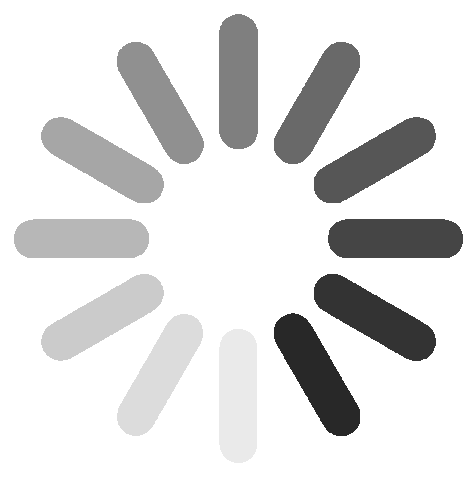

In [35]:
# plot = datamapplot.create_interactive_plot(semantic_xy, process_meta["red_team"].to_numpy().astype(str))
# plot = datamapplot.create_interactive_plot(feature_sage_xy, process_meta["red_team"].to_numpy().astype(str))
plot = datamapplot.create_interactive_plot(semantic_graphsage_xy, process_meta["red_team"].to_numpy().astype(str), hover_text=process_meta['red_team'].to_numpy().astype(str))
plot

In [19]:
sizes = [len(s) for s in sessions]
plt.hist(sizes, bins=50)
plt.xlabel("Session size")
plt.ylabel("Count")
plt.show()

NameError: name 'sessions' is not defined

In [ ]:
# for x in df_acme.columns:
    # print(x)

# df_acme

In [48]:
builder = GraphBuilder()

graph = builder.build_graph(df_acme.head(20000), llm_edge_type_extraction=True)

embeddings, labels = builder.embed_graph()
print(f"Embeddings shape: {embeddings.shape}")
print(f"Labels shape: {labels.shape}")
# builder.add_llm_assisted_edge_type_extraction(df_acme.head(250), description="Identify additional edge types for graph construction based on process execution patterns, shared artifacts, temporal proximity, etc.")

NameError: name 'GraphBuilder' is not defined

In [ ]:
subgraph = graph.subgraph(list(graph.nodes())[:1000])
subgraph.number_of_edges()
subgraph.number_of_nodes()
nx.density(subgraph)

0.00017017017017017017

In [ ]:
embeddings

array([[36.06 ,  2.   ,  0.   , ...,  1.   ,  1.   ,  1.   ],
       [22.054,  2.   ,  0.   , ...,  1.   ,  1.   ,  1.   ],
       [12.567,  2.   ,  0.   , ...,  1.   ,  1.   ,  1.   ],
       ...,
       [23.076,  0.   ,  0.   , ...,  1.   ,  1.   ,  1.   ],
       [33.837,  0.   ,  0.   , ...,  1.   ,  1.   ,  1.   ],
       [ 0.5  ,  0.   ,  0.   , ...,  1.   ,  1.   ,  1.   ]],
      shape=(17339, 14))

In [ ]:
df_acme

,pid_hash,os_family,agent_id,num_agent_id,hostname,os_pid,process_name,num_process_name,args,num_args,...,lolbas_mitre,lolc_class,lolbas_num_rows,mitre_analytic_ids,mitre_information_domains,mitre_subtypes,mitre_analytic_types,mitre_num_rows,bad_user,red_team
0,CF830E1523374BE7F0E5F91F7936443E,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,1900,wmic.exe,1,os get version /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
1,42DEC9F24F7D08578FB30A75AF68C661,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-DXJ,3748,wmic.exe,1,computersystem get dnshostname /value,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
2,A4207647384708DBA1C4552112C948F9,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,5268,wmic.exe,1,os get version /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
3,D7D35ACED1E249E503B9049D2F9599BD,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,3056,wmic.exe,1,computersystem get domain /value,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
4,224B925BA2818C792E07DE5FFD088CCC,windows,f9ac46c8-0959-4bce-82d9-556a971e7f1a,1,ACME-WS-PLU,5160,wmic.exe,1,os get caption /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668332,EEFC0AA67ACE54455AE63E69B03B9A60,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,11480,firefox.exe,1,-contentproc --channel=10748 -childid 595 -isf...,1,...,None,None,NaN,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
668333,8AF50B940C8D6F8BE4AB6619811FB954,windows,fe437745-98c3-4d17-8e19-b8ba145caced,1,ACME-DC1,6240,wintapsvcmgr.exe,1,healthcheck,1,...,None,None,NaN,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
668334,C508BC0D59E15B2F08B144F510030EB5,windows,fe437745-98c3-4d17-8e19-b8ba145caced,1,ACME-DC1,8304,dismhost.exe,1,{5a8e0c33-2aec-4972-9558-20b408b28af5},1,...,None,None,NaN,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
668335,1BD3897F9FB25164AAB6CF4FD3A1B7D7,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,8560,firefox.exe,1,-contentproc --channel=15348 -childid 1998 -is...,1,...,None,None,NaN,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0


In [ ]:
df_acme.head(20000)["red_team"]

0        0
1        0
2        0
3        0
4        0
        ..
19995    0
19996    0
19997    0
19998    0
19999    0
Name: red_team, Length: 20000, dtype: int32

In [ ]:
for l in labels:
    print(f"Label: {l}")
    if l == True:
        print("Malicious session detected!")

Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Compare two session embeddings

for i in range(len(embeddings)):
    for j in range(i+1, len(embeddings)):
        simlarity = cosine_similarity([embeddings[i]], [embeddings[j]])
        print(f"Cosine similarity between session {i} and session {j}: {simlarity}")

In [ ]:
umap_reducer = umap.UMAP(n_components=2, random_state=42)
umap_embeddings = umap_reducer.fit_transform(embeddings)
umap_mapper = umap_reducer.fit(embeddings)

C:\Users\mekae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\mekae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
C:\Users\mekae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


C:\Users\mekae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\umap\plot.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(points[:, 0], points[:, 1], s=point_size, c=color)


<Axes: >

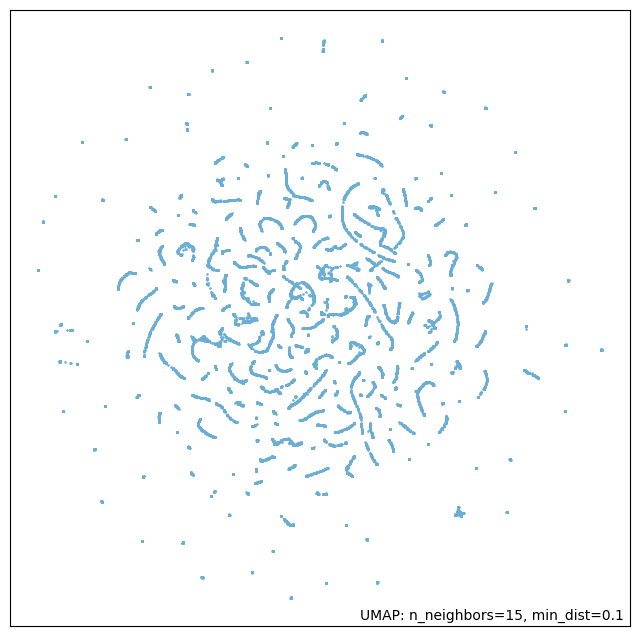

In [ ]:
umap.plot.points(umap_mapper)

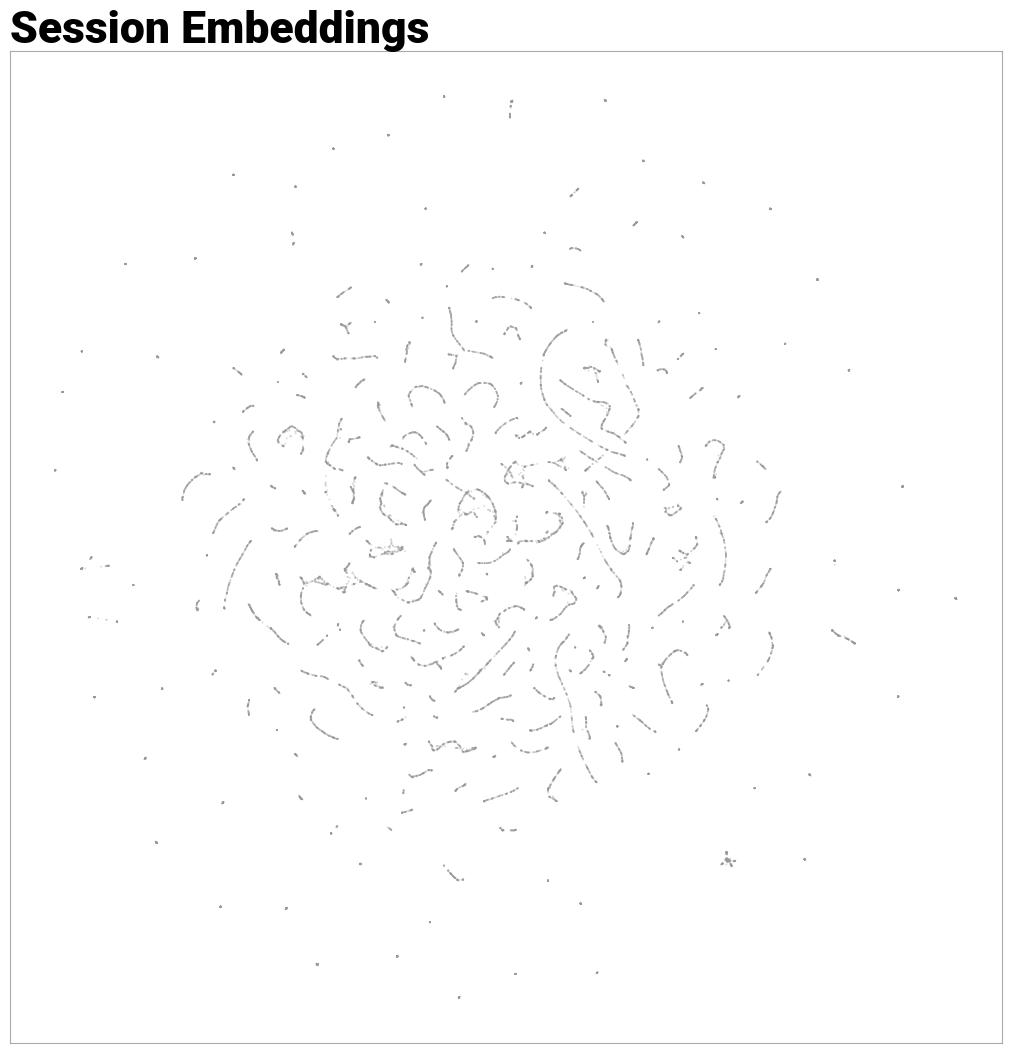

In [ ]:
plot = datamapplot.create_plot(
    umap_embeddings,
    # labels=labels,
    title="ACME4 Cyber Session Embeddings",
)

<InteractiveFigure width=100% height=800>
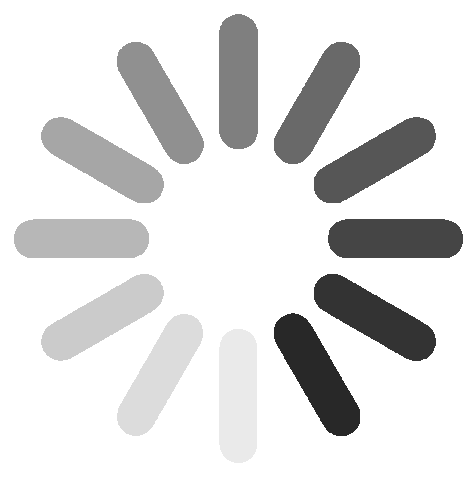

In [ ]:
interactive_plot = datamapplot.create_interactive_plot(
    umap_embeddings,
    title="ACME4 Cyber Session Embeddings",
)

interactive_plot

Embed the actual Graph

In [ ]:
from node2vec import Node2Vec

n2v = Node2Vec(graph, dimensions=128, walk_length=20, num_walks=50, workers=4)

model = n2v.fit()

ModuleNotFoundError: No module named 'node2vec'

In [ ]:
graph_session_embeds = []

for session in graph.graph['sessions']:
    node_embeds = [
        model.wv[str(node)]
        for node in session
    ]

    graph_session_embed = np.mean(node_embeds, axis=0)
    graph_session_embeds.append(graph_session_embed)

graph_embed_reduced = umap.UMAP(n_components=2, random_state=42).fit_transform(graph_session_embeds)

graph_embed_plot = datamapplot.create_interactive_plot(
    graph_embed_reduced,
    title="ACME4 Cyber Session Embeddings (Node2Vec)",
)

<InteractiveFigure width=100% height=800>
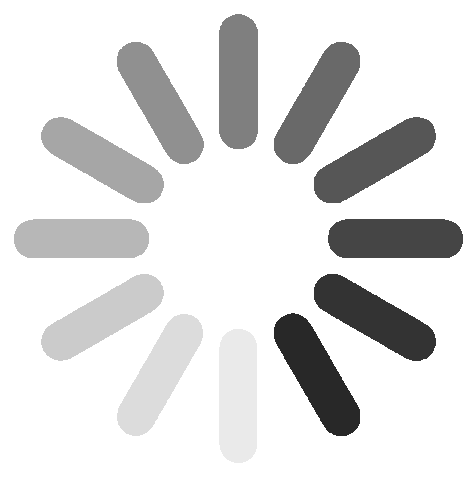

In [ ]:
graph_embed_plot = datamapplot.create_interactive_plot(
    graph_embed_reduced,
    title="ACME4 Cyber Session Embeddings (Node2Vec)",
)

graph_embed_plot

Visualize Distribution

In [ ]:
print(f"Nodes: {graph.number_of_nodes()}")
print(f"Edges: {graph.number_of_edges()}")
print(f"Connected components: {nx.number_connected_components(graph)}")

Nodes: 10000
Edges: 13362
Connected components: 8703


In [ ]:
# Add detailed diagnostics:
print(f"Total sessions: {len(sessions)}")
print(f"Singleton sessions: {sum(1 for s in sessions if len(s) == 1)}")
print(f"Sessions with 2+ nodes: {sum(1 for s in sessions if len(s) > 1)}")
print(f"Largest session: {max(len(s) for s in sessions)}")

# Check edge type distribution
edge_types = [graph.edges[e].get('edge_type', 'unknown') for e in graph.edges()]
from collections import Counter
print("\nEdge type counts:")
for et, count in Counter(edge_types).items():
    print(f"  {et}: {count}")

# Check why parent-child edges are failing
df_sample = df_acme.head(10000)
print(f"\nRows with parent_pid_hash: {df_sample['parent_pid_hash'].notna().sum()}")
print(f"Unique parent PIDs in nodes: {sum(1 for n in graph.nodes() if graph.nodes[n]['parent_pid_hash'] != 'N/A')}")

Total sessions: 9014
Singleton sessions: 8870
Sessions with 2+ nodes: 144
Largest session: 383

Edge type counts:
  same_user: 2239
  rare_artifact: 11121
  parent_child: 2

Rows with parent_pid_hash: 10000
Unique parent PIDs in nodes: 10000


Extract sessions:

In [ ]:
sessions = list(nx.connected_components(graph))
print(f"Session sizes: {[len(s) for s in sessions[:10]]}")

Session sizes: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


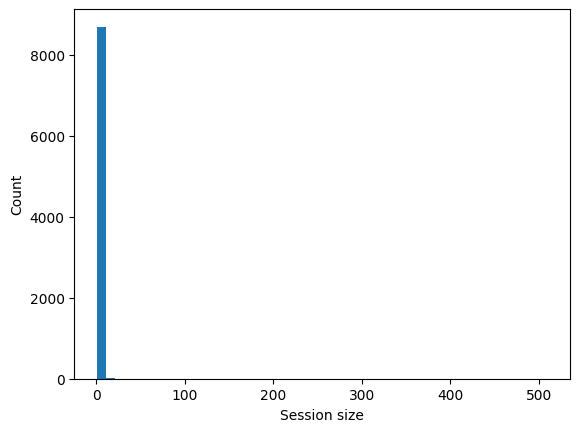

In [ ]:
sizes = [len(s) for s in sessions]
plt.hist(sizes, bins=50)
plt.xlabel("Session size")
plt.ylabel("Count")
plt.show()

In [ ]:
from pyvis.network import Network

net = Network(notebook=True, cdn_resources="remote")
net.from_nx(graph)
net.show("graph.html")

graph.html


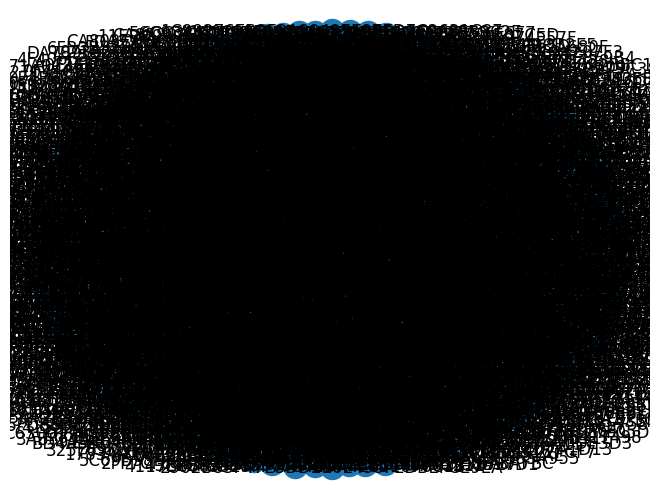

In [ ]:
# graph.nodes(data=True)
nx.draw(graph, with_labels=True)
plt.show()

In [260]:
nx.write_gexf(graph, "my_graph.gexf")